In [ ]:
from __future__ import annotations

#general naming conventions.
#in "optional" cells, the variable names start with "_". These are generally do visually peek at some data...

#use full words where possible, width instead of w. (x and y are exceptions)
#use snake case, caps for global, lowercase for local.
# follow swift-like wording (descriptive, full eglish words) -- but not camel cased...

from google.colab import drive
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import Tuple, List, Optional, Dict, Literal
from collections import defaultdict
from enum import Enum
import random, math, json, time, os
from PIL import Image, ImageDraw, ImageFont, ImageFile, ImageEnhance
import matplotlib.pyplot as plt
import cv2
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms.functional as TVF
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import roc_curve, auc, roc_auc_score, confusion_matrix
from sklearn.preprocessing import label_binarize

PathLike = Path | str
RGB = tuple[int, int, int]

MAX_AUGMENT_MULTIPLIER = 2.0  # augmented <= real

BALANCE_TARGET_COUNT_PER_CLASS = 2500
SPLIT_PERCENT_TEST = 0.0
SPLIT_PERCENT_VALIDATION = 0.15

NETWORK_POST_AUGMENTATION_INSET = 12
NETWORK_SIZE = 224

# Image-space LAB L normalization defaults (baked in)
LAB_NORMALIZATION_TARGET_MEAN = 145.0
LAB_NORMALIZATION_TARGET_STD  = 40.0

CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_GRID_SIZE = (8, 8)

DENOISE_LUMINANCE_STRENGTH = 5
DENOISE_COLOR_STRENGTH = 5
DENOISE_TEMPLATE_WINDOW_SIZE = 7
DENOISE_SEARCH_WINDOW_SIZE = 21

AUGMENTATION_BRIGHTNESS_MIN, AUGMENTATION_BRIGHTNESS_MAX = 0.90, 1.10
AUGMENTATION_CONTRAST_MIN, AUGMENTATION_CONTRAST_MAX   = 0.90, 1.10
AUGMENTATION_SATURATION_MIN, AUGMENTATION_SATURATION_MAX = 0.95, 1.05
AUGMENTATION_TRANSLATION_VALUES = [-5, 0, 5]
AUGMENTATION_ROTATION_VALUES = [0, 90, 180, 270]

torch.set_default_dtype(torch.float32)
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

print("🟢 Modules loaded.")

🟢 Modules loaded.


In [ ]:
# This will handle permissions.
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Every time, unzip the data set and save to the notebook's ephemeral workspace.
!unzip -q /content/drive/MyDrive/leuko_fatty_256.zip -d /content/leuko_fatty_256

In [ ]:
DATA_ROOT = Path("leuko_fatty_256")
if (DATA_ROOT / "leuko_fatty_256").is_dir():
    DATA_ROOT = DATA_ROOT / "leuko_fatty_256"

jpg_file_list = list(DATA_ROOT.rglob("*.jpg"))
valid_count = corrupt_count = 0
min_width = min_height = 2048
max_width = max_height = 0

ImageFile.LOAD_TRUNCATED_IMAGES = True
for jpg_file in jpg_file_list:
    try:
        with Image.open(jpg_file) as image:
            width, height = image.size
            valid_count += 1
            min_width = min(min_width, width)
            min_height = min(min_height, height)
            max_width = max(max_width, width)
            max_height = max(max_height, height)
    except Exception:
        corrupt_count += 1

if corrupt_count: print(f"⚠️ {corrupt_count} corrupt image files.")
if (min_width, min_height) == (max_width, max_height):
    print(f"🟢 {valid_count} images with ubiquitous dimensions, {min_width} x {min_height} pixels.")
else:
    print(f"🟡 {valid_count} images of mixed dimensions\n   ({min_width} to {max_width}) x ({min_height} to {max_height}) pixels.")

ImageFile.LOAD_TRUNCATED_IMAGES = False

🟢 23953 images with ubiquitous dimensions, 288 x 288 pixels.


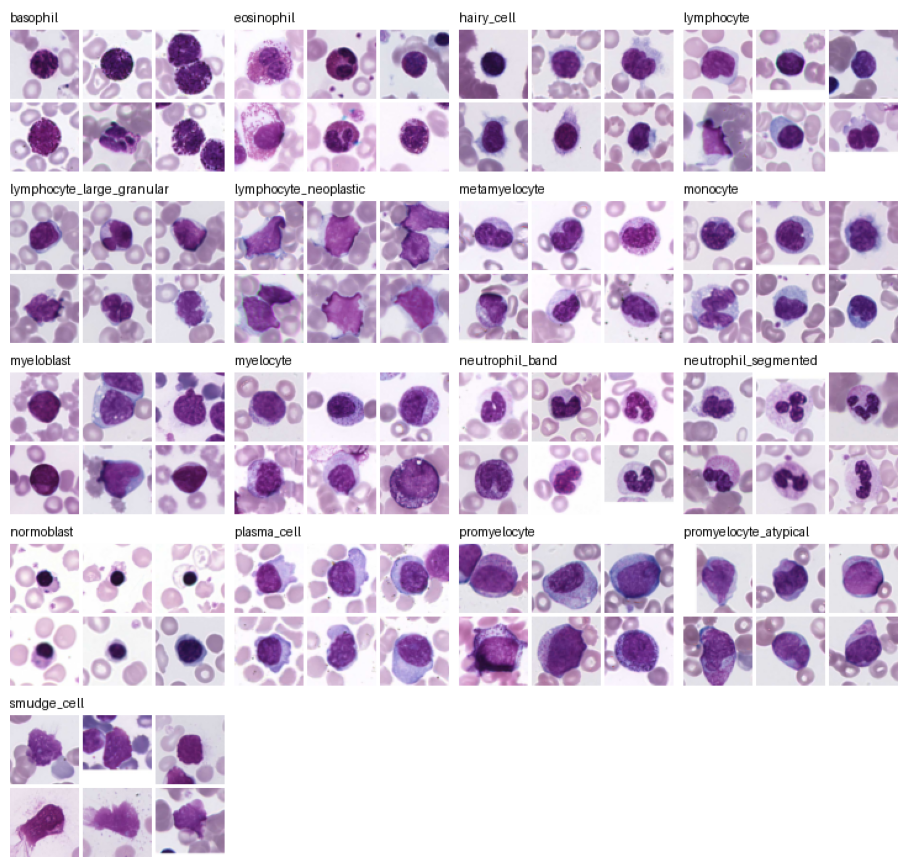

In [ ]:
# Peek at the data, in a sexy fashion. Skip if broken.
_class_directories = sorted(
    p for p in DATA_ROOT.iterdir()
    if p.is_dir() and not p.name.startswith("__")
)
_thumbnail_size = 56; _images_per_class = 6
_panel_columns = 3; _panel_rows = 2
_image_padding = 3; _panel_padding = 8; _label_height = 16
_classes_per_row = 4
_class_count = len(_class_directories); _font = ImageFont.load_default()
_panel_width  = _panel_columns * _thumbnail_size + (_panel_columns - 1) * _image_padding
_panel_height = _label_height + _panel_rows * _thumbnail_size + (_panel_rows - 1) * _image_padding
_grid_columns = min(_classes_per_row, _class_count) if _class_count else _classes_per_row
_grid_rows    = math.ceil(_class_count / _grid_columns) if _class_count else 1
_canvas_width  = _grid_columns * _panel_width  + (_grid_columns - 1) * _panel_padding
_canvas_height = _grid_rows    * _panel_height + (_grid_rows    - 1) * _panel_padding
_canvas = Image.new("RGB", (_canvas_width, _canvas_height), "white")
_draw = ImageDraw.Draw(_canvas)
_image_positions = [
    (column_index, row_index)
    for row_index in range(_panel_rows)
    for column_index in range(_panel_columns)
]
for class_index, class_directory in enumerate(_class_directories):
    jpg_files = sorted(class_directory.rglob("*.jpg"))
    if not jpg_files: continue
    sample_images = random.sample(jpg_files, min(_images_per_class, len(jpg_files)))
    grid_row = class_index // _grid_columns; grid_column = class_index % _grid_columns
    x_offset = grid_column * (_panel_width + _panel_padding); y_offset = grid_row * (_panel_height + _panel_padding)
    _draw.text((x_offset, y_offset), class_directory.name, fill=(0, 0, 0), font=_font)
    for image_path, (column_index, row_index) in zip(sample_images, _image_positions):
        with Image.open(image_path) as image:
            image = image.convert("RGB").resize((_thumbnail_size, _thumbnail_size), Image.BILINEAR)
        pixel_x = x_offset + column_index * (_thumbnail_size + _image_padding)
        pixel_y = y_offset + _label_height + row_index * (_thumbnail_size + _image_padding)
        _canvas.paste(image, (pixel_x, pixel_y))
plt.figure(figsize=(12, max(4, _grid_rows * 2.2))); plt.imshow(_canvas); plt.axis("off"); plt.show()

In [ ]:
def tensor_to_pil(tensor: torch.Tensor) -> Image.Image:
    tensor = tensor.detach()
    tensor = torch.clamp(tensor, 0.0, 1.0)
    tensor_u8 = torch.round(tensor * 255.0).clamp(0.0, 255.0).to(torch.uint8)
    return TVF.to_pil_image(tensor_u8)

def pil_to_tensor(img: Image.Image) -> torch.Tensor:
    if img.mode != "RGB":
        img = img.convert("RGB")
    return TVF.pil_to_tensor(img).to(dtype=torch.float32).div_(255.0)  # [C,H,W] in 0..1

@dataclass(frozen=True)
class Augmentation:
    flip_horizontal: bool
    rotation_degrees: int
    translation_x: int
    translation_y: int
    brightness_factor: float = 1.0
    contrast_factor: float = 1.0
    saturation_factor: float = 1.0

def _apply_color_pil(image: Image.Image, augmentation: Augmentation) -> Image.Image:
    output_image = image if image.mode == "RGB" else image.convert("RGB")
    if augmentation.brightness_factor != 1.0:
        enhancer = ImageEnhance.Brightness(output_image)
        output_image = enhancer.enhance(float(augmentation.brightness_factor))
    if augmentation.contrast_factor != 1.0:
        enhancer = ImageEnhance.Contrast(output_image)
        output_image = enhancer.enhance(float(augmentation.contrast_factor))
    if augmentation.saturation_factor != 1.0:
        enhancer = ImageEnhance.Color(output_image)
        output_image = enhancer.enhance(float(augmentation.saturation_factor))
    return output_image

def _apply_geometry_pil(
    image: Image.Image,
    augmentation: Augmentation,
    background_rgb: RGB,
) -> Image.Image:
    # Flip
    output_image = (
        image.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
        if augmentation.flip_horizontal
        else image
    )

    # Rotate (only the standard right angles)
    rotation_degrees = augmentation.rotation_degrees % 360
    if rotation_degrees == 90:
        output_image = output_image.transpose(Image.Transpose.ROTATE_90)
    elif rotation_degrees == 180:
        output_image = output_image.transpose(Image.Transpose.ROTATE_180)
    elif rotation_degrees == 270:
        output_image = output_image.transpose(Image.Transpose.ROTATE_270)
    elif rotation_degrees != 0:
        raise ValueError("rotation_degrees must be one of {0, 90, 180, 270}")

    if output_image.mode != "RGB":
        output_image = output_image.convert("RGB")

    image_array = np.asarray(output_image); image_height, image_width, _channels = image_array.shape
    translation_x = int(augmentation.translation_x); translation_y = int(augmentation.translation_y)
    background_r, background_g, background_b = (int(background_rgb[0]), int(background_rgb[1]), int(background_rgb[2]))
    output_array = np.empty((image_height, image_width, 3), dtype=image_array.dtype)
    output_array[:, :] = np.array([background_r, background_g, background_b], dtype=image_array.dtype)
    source_x0 = max(0, -translation_x); source_y0 = max(0, -translation_y)
    source_x1 = min(image_width, image_width - translation_x); source_y1 = min(image_height, image_height - translation_y)
    destination_x0 = max(0, translation_x); destination_y0 = max(0, translation_y)
    destination_x1 = destination_x0 + (source_x1 - source_x0); destination_y1 = destination_y0 + (source_y1 - source_y0)

    if source_x1 > source_x0 and source_y1 > source_y0:
        output_array[destination_y0:destination_y1, destination_x0:destination_x1] = image_array[source_y0:source_y1, source_x0:source_x1]

    return Image.fromarray(output_array)

def apply_augmentation(
    image: Image.Image,
    augmentation: Augmentation,
    background_rgb: RGB = (255, 255, 255),
) -> Image.Image:
    translation_x = int(augmentation.translation_x); translation_y = int(augmentation.translation_y)
    rotation_degrees = augmentation.rotation_degrees % 360
    needs_geometry = (augmentation.flip_horizontal or rotation_degrees != 0
                      or translation_x != 0 or translation_y != 0)
    if needs_geometry:
        output_image = _apply_geometry_pil(image, augmentation, background_rgb)
    elif image.mode != "RGB":
        output_image = image.convert("RGB")
    else:
        output_image = image
    needs_color = (augmentation.brightness_factor != 1.0 or augmentation.contrast_factor != 1.0 or
                   augmentation.saturation_factor != 1.0)
    if needs_color:
        return _apply_color_pil(output_image, augmentation)
    else:
        return output_image

def make_random_augmentation(random_generator: random.Random) -> Augmentation:
    return Augmentation(
        flip_horizontal=random_generator.choice([False, True]),
        rotation_degrees=random_generator.choice(AUGMENTATION_ROTATION_VALUES),
        translation_x=random_generator.choice(AUGMENTATION_TRANSLATION_VALUES),
        translation_y=random_generator.choice(AUGMENTATION_TRANSLATION_VALUES),
        brightness_factor=random_generator.uniform(AUGMENTATION_BRIGHTNESS_MIN, AUGMENTATION_BRIGHTNESS_MAX),
        contrast_factor=random_generator.uniform(AUGMENTATION_CONTRAST_MIN, AUGMENTATION_CONTRAST_MAX),
        saturation_factor=random_generator.uniform(AUGMENTATION_SATURATION_MIN, AUGMENTATION_SATURATION_MAX),
    )

@dataclass(frozen=True)
class FileReference:
    path: Path
    def __init__(self, path: PathLike):
        object.__setattr__(self, "path", Path(path))

@dataclass(frozen=True)
class FileReferenceAndAugmentation:
    file_reference: FileReference
    augmentation: Optional[Augmentation]


class_directories = sorted(
    class_directory
    for class_directory in DATA_ROOT.iterdir()
    if class_directory.is_dir()
    and not class_directory.name.startswith("__")
)

file_reference_table = defaultdict(list)
all_file_references: List[FileReference] = []

for class_directory in class_directories:
    class_name = class_directory.name
    for file_path in sorted(class_directory.rglob("*.jpg")):
        if file_path.is_file() and file_path.suffix.lower() == ".jpg":
            file_reference = FileReference(file_path)
            file_reference_table[class_name].append(file_reference)
            all_file_references.append(file_reference)

class_directories = sorted(
    class_directory
    for class_directory in DATA_ROOT.iterdir()
    if class_directory.is_dir()
    and not class_directory.name.startswith("__")
)

class_names: List[str] = [ class_directory.name for class_directory in class_directories ]
class_count = len(class_names)
class_index_table: Dict[str, int] = { class_name: class_index for class_index, class_name in enumerate(class_names) }
class_name_table: Dict[int, str] = { class_index: class_name for class_name, class_index in class_index_table.items() }

for class_name in class_names:
    class_index = class_index_table[class_name]
    class_name_refetch = class_name_table[class_index]
    length = len(file_reference_table[class_name])
    print(f"🔍 Found class: {class_name} ({class_index} => {class_name_refetch}) with {length} samples.")

🔍 Found class: basophil (0 => basophil) with 616 samples.
🔍 Found class: eosinophil (1 => eosinophil) with 2000 samples.
🔍 Found class: hairy_cell (2 => hairy_cell) with 2000 samples.
🔍 Found class: lymphocyte (3 => lymphocyte) with 2000 samples.
🔍 Found class: lymphocyte_large_granular (4 => lymphocyte_large_granular) with 1849 samples.
🔍 Found class: lymphocyte_neoplastic (5 => lymphocyte_neoplastic) with 180 samples.
🔍 Found class: metamyelocyte (6 => metamyelocyte) with 483 samples.
🔍 Found class: monocyte (7 => monocyte) with 2000 samples.
🔍 Found class: myeloblast (8 => myeloblast) with 2000 samples.
🔍 Found class: myelocyte (9 => myelocyte) with 747 samples.
🔍 Found class: neutrophil_band (10 => neutrophil_band) with 687 samples.
🔍 Found class: neutrophil_segmented (11 => neutrophil_segmented) with 2000 samples.
🔍 Found class: normoblast (12 => normoblast) with 2000 samples.
🔍 Found class: plasma_cell (13 => plasma_cell) with 1658 samples.
🔍 Found class: promyelocyte (14 => prom

In [ ]:
train_file_reference_table: Dict[str, List[FileReference]] = {}
validation_file_reference_table: Dict[str, List[FileReference]] = {}
test_file_reference_table: Dict[str, List[FileReference]] = {}

SPLIT_SEED = 777

def _stable_u32(text: str) -> int:
    import hashlib
    digest = hashlib.blake2b(text.encode("utf-8"),digest_size=4).digest()
    return int.from_bytes(digest, "little")

def split_list_deterministic(
    items: List[FileReference],
    seed: int,
) -> tuple[List[FileReference], List[FileReference], List[FileReference]]:
    items = sorted(
        items,
        key=lambda file_reference: file_reference.path.as_posix(),
    )
    items = list(items)
    random_generator = random.Random(seed)
    random_generator.shuffle(items)
    item_count = len(items)
    test_count = int(item_count * SPLIT_PERCENT_TEST)
    validation_count = int(item_count * SPLIT_PERCENT_VALIDATION)
    train_count = item_count - test_count - validation_count
    if item_count and train_count <= 0:
        train_count = 1
        leftover = item_count - train_count
        validation_count = min(validation_count, leftover)
        test_count = min(test_count, leftover - validation_count)

    train_items = items[:train_count]
    validation_items = items[train_count:train_count + validation_count]
    test_items = items[train_count + validation_count:train_count + validation_count + test_count]
    return train_items, validation_items, test_items

for class_name in class_names:
    class_file_references = file_reference_table.get(class_name, [])
    class_seed = _stable_u32(f"{SPLIT_SEED}|{class_name}")
    train_items, validation_items, test_items = split_list_deterministic(class_file_references, class_seed)
    train_file_reference_table[class_name] = train_items
    validation_file_reference_table[class_name] = validation_items
    test_file_reference_table[class_name] = test_items


holdout_file_reference_table: Dict[str, List[FileReference]] = {
    class_name: (
        validation_file_reference_table[class_name]
        + test_file_reference_table[class_name]
    )
    for class_name in class_names
}

for class_name in class_names:
    train_count = len(train_file_reference_table.get(class_name, []))
    validation_count = len(validation_file_reference_table.get(class_name, []))
    test_count = len(test_file_reference_table.get(class_name, []))

    print(
        f"{class_name:>20s} | "
        f"train={train_count:4d} | "
        f"val={validation_count:4d} | "
        f"test={test_count:4d}"
    )

def build_balanced_train_items(class_name: str, epoch_seed: int) -> List[FileReferenceAndAugmentation]:
    base = train_file_reference_table.get(class_name, [])
    items = [FileReferenceAndAugmentation(fr, None) for fr in base]
    if not base:
        return items

    target = BALANCE_TARGET_COUNT_PER_CLASS  # 2000
    max_augmented = int(len(base) * MAX_AUGMENT_MULTIPLIER)
    max_total = len(base) + max_augmented
    effective_target = min(target, max_total)

    rng = random.Random(_stable_u32(f"{SPLIT_SEED}|balance|{class_name}|epoch{epoch_seed}"))

    while len(items) < effective_target:
        fr = rng.choice(base)
        items.append(FileReferenceAndAugmentation(fr, make_random_augmentation(rng)))

    if len(items) > effective_target:
        rng.shuffle(items)
        items = items[:effective_target]

    return items

In [ ]:
def build_and_pad_data(
    *,
    class_names: List[str],
    build_balanced_train_items,  # expects (class_name: str, trial_seed: int) -> List[...]
    validation_file_reference_table: Dict[str, List[FileReference]],
    test_file_reference_table: Dict[str, List[FileReference]],
    epoch_seed: int,
    verbose: bool = True,
) -> Tuple[
    Dict[str, List[FileReferenceAndAugmentation]],
    Dict[str, List[FileReferenceAndAugmentation]],
    Dict[str, List[FileReferenceAndAugmentation]],
    List[FileReferenceAndAugmentation],
    List[FileReferenceAndAugmentation],
    List[FileReferenceAndAugmentation],
]:
    train_augmented_table: Dict[str, List[FileReferenceAndAugmentation]] = {}
    validation_augmented_table: Dict[str, List[FileReferenceAndAugmentation]] = {}
    test_augmented_table: Dict[str, List[FileReferenceAndAugmentation]] = {}

    train_augmented_all: List[FileReferenceAndAugmentation] = []
    validation_augmented_all: List[FileReferenceAndAugmentation] = []
    test_augmented_all: List[FileReferenceAndAugmentation] = []

    for class_name in class_names:
        train_items = build_balanced_train_items(class_name, int(epoch_seed))
        # 👇 pass the seed
        #train_items = build_balanced_train_items(class_name, trial_seed=trial_seed)

        train_augmented_table[class_name] = train_items
        train_augmented_all.extend(train_items)

        augmentation_count = sum(1 for item in train_items if item.augmentation is not None)
        total_count = len(train_items)
        real_count = total_count - augmentation_count

        validation_refs = validation_file_reference_table.get(class_name, [])
        validation_items = [FileReferenceAndAugmentation(fr, None) for fr in validation_refs]
        validation_augmented_table[class_name] = validation_items
        validation_augmented_all.extend(validation_items)

        test_refs = test_file_reference_table.get(class_name, [])
        test_items = [FileReferenceAndAugmentation(fr, None) for fr in test_refs]
        test_augmented_table[class_name] = test_items
        test_augmented_all.extend(test_items)

        if verbose:
            print(
                f"✅ {class_name}: "
                f"train={total_count} (real={real_count}, augmented={augmentation_count}) | "
                f"validation={len(validation_items)} | "
                f"test={len(test_items)}"
            )

    return (
        train_augmented_table,
        validation_augmented_table,
        test_augmented_table,
        train_augmented_all,
        validation_augmented_all,
        test_augmented_all,
    )

(
    train_augmented_table,
    validation_augmented_table,
    test_augmented_table,
    train_augmented_all,
    validation_augmented_all,
    test_augmented_all,
) = build_and_pad_data(
    class_names=class_names,
    build_balanced_train_items=build_balanced_train_items,
    validation_file_reference_table=validation_file_reference_table,
    test_file_reference_table=test_file_reference_table,
    verbose=True,
    epoch_seed=0
)


✅ basophil: train=1572 (real=524, augmented=1048) | validation=92 | test=0
✅ eosinophil: train=2500 (real=1700, augmented=800) | validation=300 | test=0
✅ hairy_cell: train=2500 (real=1700, augmented=800) | validation=300 | test=0
✅ lymphocyte: train=2500 (real=1700, augmented=800) | validation=300 | test=0
✅ lymphocyte_large_granular: train=2500 (real=1572, augmented=928) | validation=277 | test=0
✅ lymphocyte_neoplastic: train=459 (real=153, augmented=306) | validation=27 | test=0
✅ metamyelocyte: train=1233 (real=411, augmented=822) | validation=72 | test=0
✅ monocyte: train=2500 (real=1700, augmented=800) | validation=300 | test=0
✅ myeloblast: train=2500 (real=1700, augmented=800) | validation=300 | test=0
✅ myelocyte: train=1905 (real=635, augmented=1270) | validation=112 | test=0
✅ neutrophil_band: train=1752 (real=584, augmented=1168) | validation=103 | test=0
✅ neutrophil_segmented: train=2500 (real=1700, augmented=800) | validation=300 | test=0
✅ normoblast: train=2500 (real=

In [ ]:
def crop_inset_and_resize(
    image: Image.Image,
    inset: int,
    network_size: int,
) -> Image.Image:
    if image.mode != "RGB":
        image = image.convert("RGB")
    width, height = image.size
    inset = int(max(0, inset))
    crop_width = width - 2 * inset
    crop_height = height - 2 * inset
    if crop_width <= 1 or crop_height <= 1:
        square_size = max(1, min(width, height))
        left = (width - square_size) // 2
        top = (height - square_size) // 2
        image = image.crop((left, top, left + square_size, top + square_size))
    else:
        image = image.crop((inset, inset, width - inset, height - inset))
    return image.resize((network_size, network_size), resample=Image.Resampling.BILINEAR)

def apply_clahe(
    image: Image.Image
) -> Image.Image:
    if image.mode != "RGB":
        image = image.convert("RGB")
    rgb_u8 = np.asarray(image)
    lab_u8 = cv2.cvtColor(rgb_u8, cv2.COLOR_RGB2LAB)
    l_u8, a_u8, b_u8 = cv2.split(lab_u8)
    clahe = cv2.createCLAHE(
        clipLimit=float(CLAHE_CLIP_LIMIT),
        tileGridSize=tuple(CLAHE_TILE_GRID_SIZE),
    )
    l2_u8 = clahe.apply(l_u8)
    lab2_u8 = cv2.merge([l2_u8, a_u8, b_u8])
    rgb2_u8 = cv2.cvtColor(lab2_u8, cv2.COLOR_LAB2RGB)
    return Image.fromarray(rgb2_u8)

def apply_denoise(
    image: Image.Image,
) -> Image.Image:
    if image.mode != "RGB":
        image = image.convert("RGB")
    rgb_u8 = np.asarray(image)
    bgr_u8 = cv2.cvtColor(rgb_u8, cv2.COLOR_RGB2BGR)
    denoised_bgr_u8 = cv2.fastNlMeansDenoisingColored(
        bgr_u8, None,
        h=int(DENOISE_LUMINANCE_STRENGTH), hColor=int(DENOISE_COLOR_STRENGTH),
        templateWindowSize=int(DENOISE_TEMPLATE_WINDOW_SIZE),
        searchWindowSize=int(DENOISE_SEARCH_WINDOW_SIZE),
    )
    denoised_rgb_u8 = cv2.cvtColor(denoised_bgr_u8, cv2.COLOR_BGR2RGB)
    return Image.fromarray(denoised_rgb_u8)

def apply_lab(
    image: Image.Image,
) -> Image.Image:
    if image.mode != "RGB":
        image = image.convert("RGB")
    rgb_u8 = np.asarray(image)
    lab_f32 = cv2.cvtColor(rgb_u8, cv2.COLOR_RGB2LAB).astype(np.float32)
    l_f32, a_f32, b_f32 = cv2.split(lab_f32)
    epsilon = 1e-6
    luminance_mean = float(l_f32.mean())
    luminance_std = float(l_f32.std()) + epsilon
    l_f32 = (l_f32 - luminance_mean) / luminance_std * float(LAB_NORMALIZATION_TARGET_STD) + float(LAB_NORMALIZATION_TARGET_MEAN)
    l_u8 = np.clip(l_f32, 0.0, 255.0).astype(np.uint8)
    a_u8 = np.clip(a_f32, 0.0, 255.0).astype(np.uint8)
    b_u8 = np.clip(b_f32, 0.0, 255.0).astype(np.uint8)
    rgb2_u8 = cv2.cvtColor(cv2.merge([l_u8, a_u8, b_u8]), cv2.COLOR_LAB2RGB)
    return Image.fromarray(rgb2_u8)

def apply_reinhard(image: Image.Image) -> Image.Image:
    if image.mode != "RGB":
        image = image.convert("RGB")
    rgb_u8 = np.asarray(image)
    lab_f32 = cv2.cvtColor(rgb_u8, cv2.COLOR_RGB2LAB).astype(np.float32)
    l_f32, a_f32, b_f32 = cv2.split(lab_f32)
    target_l_mean, target_l_std = 165.0, 35.0
    target_a_mean, target_a_std = 135.0, 12.0
    target_b_mean, target_b_std = 140.0, 12.0
    epsilon = 1e-6
    source_l_mean, source_l_std = float(l_f32.mean()), float(l_f32.std()) + epsilon
    source_a_mean, source_a_std = float(a_f32.mean()), float(a_f32.std()) + epsilon
    source_b_mean, source_b_std = float(b_f32.mean()), float(b_f32.std()) + epsilon
    l_f32 = (l_f32 - source_l_mean) / source_l_std * target_l_std + target_l_mean
    a_f32 = (a_f32 - source_a_mean) / source_a_std * target_a_std + target_a_mean
    b_f32 = (b_f32 - source_b_mean) / source_b_std * target_b_std + target_b_mean
    lab_u8 = cv2.merge([
        np.clip(l_f32, 0.0, 255.0), np.clip(a_f32, 0.0, 255.0), np.clip(b_f32, 0.0, 255.0),
    ]).astype(np.uint8)
    rgb2_u8 = cv2.cvtColor(lab_u8, cv2.COLOR_LAB2RGB)
    return Image.fromarray(rgb2_u8)

class PreprocessingMode(Enum):
    LAB = "lab"
    REINHARD = "reinhard"

@dataclass(frozen=True)
class PreprocessConfig:
    mode: Optional[PreprocessingMode] = None
    clahe: bool = False
    denoise: bool = False

def preprocess_image(
    image: Image.Image,
    mode: Optional[PreprocessingMode],
    clahe: bool,
    denoise: bool,
) -> Image.Image:
    if mode is not None:
        if mode == PreprocessingMode.LAB:
            image = apply_lab(image)
        elif mode == PreprocessingMode.REINHARD:
            image = apply_reinhard(image)
        else:
            raise ValueError(f"Unknown PreprocessingMode: {mode!r}")
    if clahe:
        image = apply_clahe(image)
    if denoise:
        image = apply_denoise(image)
    return image

def image_from_file_reference(file_reference: FileReference) -> Image.Image:
    """Load an image from disk with no augmentation."""
    with Image.open(file_reference.path) as im:
        im = im.convert("RGB") if im.mode != "RGB" else im.copy()
    return im

def image_from_file_reference_augmented(fra: FileReferenceAndAugmentation) -> Image.Image:
    """Load an image and apply augmentation if present."""
    img = image_from_file_reference(fra.file_reference)
    return apply_augmentation(img, fra.augmentation) if fra.augmentation is not None else img

Samples:
  leuko_fatty_256/leuko_fatty_256/monocyte/monocyte_1007.jpg
  leuko_fatty_256/leuko_fatty_256/myeloblast/myeloblast_1105.jpg
  leuko_fatty_256/leuko_fatty_256/myeloblast/myeloblast_0588.jpg
  leuko_fatty_256/leuko_fatty_256/promyelocyte/promyelocyte_0707.jpg


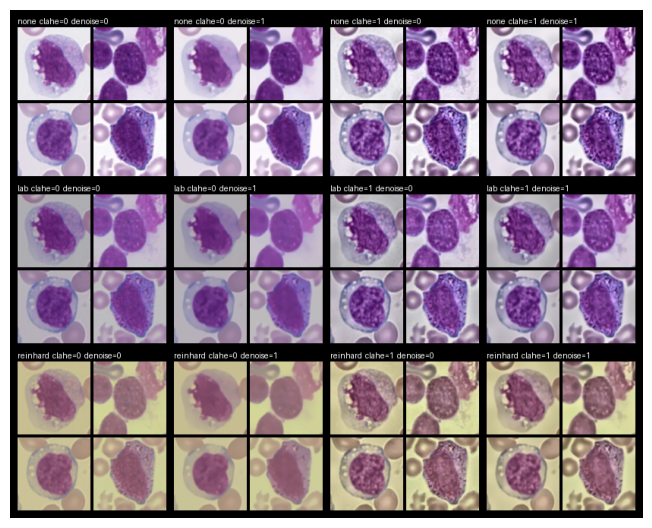

In [ ]:
# Peek at preprocessing combinations (no DataLoader). Optional cell. Skip if it's broken.
_seed = 777; _random_generator = random.Random(_seed)
_samples_per_cell = 4; _samples_grid_columns = 2; _samples_grid_rows = 2
_thumbnail_size = 96; _thumbnail_padding = 4; _panel_padding = 10; _label_height = 14; _outer_padding = 10
_font = ImageFont.load_default()
if len(jpg_file_list) == 0: raise RuntimeError(f"No .jpg files found under {DATA_ROOT}")
_sample_file_paths = _random_generator.sample(jpg_file_list, k=min(_samples_per_cell, len(jpg_file_list)))
print("Samples:"); [print(" ", _file_path) for _file_path in _sample_file_paths]
_mode_rows: list[tuple[str, Optional[PreprocessingMode]]] = [("none", None), ("lab", PreprocessingMode.LAB), ("reinhard", PreprocessingMode.REINHARD)]
_flag_columns: list[tuple[int, int]] = [(0, 0), (0, 1), (1, 0), (1, 1)]
_cell_image_width  = _samples_grid_columns * _thumbnail_size + (_samples_grid_columns - 1) * _thumbnail_padding
_cell_image_height = _samples_grid_rows    * _thumbnail_size + (_samples_grid_rows    - 1) * _thumbnail_padding
_cell_width = _cell_image_width; _cell_height = _label_height + _cell_image_height
_canvas_width  = len(_flag_columns) * _cell_width  + (len(_flag_columns) - 1) * _panel_padding + 2 * _outer_padding
_canvas_height = len(_mode_rows)    * _cell_height + (len(_mode_rows)    - 1) * _panel_padding + 2 * _outer_padding
_canvas = Image.new("RGB", (_canvas_width, _canvas_height), (0, 0, 0)); _draw = ImageDraw.Draw(_canvas)
for _row_index, (_mode_label, _mode_value) in enumerate(_mode_rows):
    for _column_index, (_clahe_flag, _denoise_flag) in enumerate(_flag_columns):
        _x0 = _outer_padding + _column_index * (_cell_width + _panel_padding)
        _y0 = _outer_padding + _row_index    * (_cell_height + _panel_padding)
        _draw.text((_x0, _y0), f"{_mode_label}  clahe={_clahe_flag}  denoise={_denoise_flag}", fill=(255, 255, 255), font=_font)
        for _sample_index, _file_path in enumerate(_sample_file_paths):
            _sample_row = _sample_index // _samples_grid_columns; _sample_column = _sample_index % _samples_grid_columns
            with Image.open(_file_path) as _image: _image_rgb = _image.convert("RGB")
            _image_rgb = crop_inset_and_resize(image=_image_rgb, inset=int(NETWORK_POST_AUGMENTATION_INSET), network_size=int(NETWORK_SIZE))
            _processed = preprocess_image(image=_image_rgb, mode=_mode_value, clahe=bool(_clahe_flag), denoise=bool(_denoise_flag))
            _thumbnail = _processed.resize((_thumbnail_size, _thumbnail_size), resample=Image.Resampling.BILINEAR)
            _pixel_x = _x0 + _sample_column * (_thumbnail_size + _thumbnail_padding)
            _pixel_y = _y0 + _label_height + _sample_row * (_thumbnail_size + _thumbnail_padding)
            _canvas.paste(_thumbnail, (_pixel_x, _pixel_y))
plt.figure(figsize=(14, max(4, len(_mode_rows) * 2.2))); plt.imshow(_canvas); plt.axis("off"); plt.show()

In [ ]:
class LeukocyteDataSet(Dataset):
    def __init__(
        self,
        items: List[FileReferenceAndAugmentation],
        class_index_lut: Dict[str, int],
        data_root: Optional[Path] = None,
        preprocess_config: Optional[PreprocessConfig] = None
    ):
        self.items = items
        self.class_index_lut = class_index_lut
        self.data_root = data_root
        self.preprocess_config = preprocess_config
        self.network_size = int(NETWORK_SIZE)
        self.post_augmentation_inset = int(NETWORK_POST_AUGMENTATION_INSET)

    def __len__(self) -> int:
        return len(self.items)

    def _class_name_from_path(self, p: Path) -> str:
        # data_root lets you support either absolute paths or relative-to-root paths
        if self.data_root is None:
            return p.parent.name
        return p.relative_to(self.data_root).parts[0]

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, int]:
        fra = self.items[idx]
        image = image_from_file_reference_augmented(fra)
        image = crop_inset_and_resize(
            image=image,
            inset=self.post_augmentation_inset,
            network_size=self.network_size,
        )

        config = self.preprocess_config
        if config is not None:
            image = preprocess_image(
                image=image,
                mode=config.mode,
                clahe=bool(config.clahe),
                denoise=bool(config.denoise),
            )

        x = (
            TVF.pil_to_tensor(image)
            .to(dtype=torch.float32)
            .div_(255.0)
            .contiguous()
        )
        file_path = fra.file_reference.path
        class_name = self._class_name_from_path(file_path)
        class_index = int(self.class_index_lut[class_name])

        return x, class_index


In [ ]:
class CamilaModel(nn.Module):

    def __init__(
        self,
        num_classes: int,
        dropout: float = 0.2,
        stem: int = 32,
    ):
        super().__init__()
        def conv_bn_silu(in_channels: int, out_channels: int, kernel_size: int = 3, padding: int = 1) -> nn.Module:
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, padding=padding, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.SiLU(inplace=True),
            )
        c1 = stem          # 32
        c2 = stem * 2      # 64
        c3 = stem * 4      # 128
        c4 = stem * 8      # 256

        self.foot_1 = nn.Sequential(
            conv_bn_silu(3,  c1), nn.MaxPool2d(2),
            conv_bn_silu(c1, c2), nn.MaxPool2d(2),
            conv_bn_silu(c2, c3), nn.MaxPool2d(2),
            conv_bn_silu(c3, c4),
            conv_bn_silu(c4, c4),
            nn.MaxPool2d(2),
        )

        flat_dim = c4 * 14 * 14

        self.head = nn.Sequential(
          nn.AdaptiveAvgPool2d(1),          # [B, c4, 1, 1]
          nn.Flatten(1),                    # [B, c4]
          nn.Linear(c4, 1024),
          nn.SiLU(inplace=True),            # keep SiLU for consistency
          nn.Dropout(p=float(dropout)),
          nn.Linear(1024, int(num_classes)),
      )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.foot_1(x)
        return self.head(x)

In [ ]:
NUM_CLASSES = len(class_index_table)

def get_device() -> torch.device:
    if torch.cuda.is_available(): return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available(): return torch.device("mps")
    return torch.device("cpu")

DEVICE = get_device()
print("Device:", DEVICE)
print("Num classes:", NUM_CLASSES)

PIN_MEMORY = False
NUM_WORKERS = 0

# ---- stats + io helpers (reuse your existing ones, but ensuring they exist) ----
@dataclass(frozen=True)
class TrainStats:
    loss: float
    acc: float

def _append_jsonl(path: Path, row: Dict) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("a", encoding="utf-8") as f:
        f.write(json.dumps(row) + "\n")

def _load_jsonl(path: Path) -> list[Dict]:
    if not path.exists(): return []
    out: list[Dict] = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line: out.append(json.loads(line))
    return out

def ckpt_path(models_dir: Path, epoch: int) -> Path:
    return models_dir / f"train_model_{epoch:04d}.pt"

def save_checkpoint(path: Path, *, model: nn.Module, optimizer: torch.optim.Optimizer, classes: list[str], epoch: int, best_acc: float) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            "epoch": int(epoch),
            "classes": classes,
            "arch": model.__class__.__name__,
            "best_acc": float(best_acc),
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
        },
        path,
    )

def load_checkpoint_into_existing_strict(path: Path, *, model: nn.Module, optimizer: torch.optim.Optimizer, device: torch.device) -> tuple[int, float]:
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    if "optimizer_state_dict" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    return int(ckpt.get("epoch", 0)), float(ckpt.get("best_acc", 0.0))

def _latest_checkpoint_path(models_dir: Path) -> Optional[Path]:
    if not models_dir.exists(): return None
    candidates = sorted(models_dir.glob("train_model_*.pt"))
    return candidates[-1] if candidates else None

def fire_epoch(
    *,
    device: torch.device,
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: Optional[torch.optim.Optimizer],
    is_train: bool,
) -> TrainStats:
    model.train() if is_train else model.eval()
    if is_train and optimizer is None:
        raise ValueError("optimizer must not be None when is_train=True")

    total_loss = 0.0
    correct = 0
    total = 0

    context = torch.enable_grad() if is_train else torch.inference_mode()

    with context:
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            if is_train:
                optimizer.zero_grad(set_to_none=True)

            logits = model(xb)
            loss = criterion(logits, yb)

            if is_train:
                loss.backward()
                optimizer.step()

            batch_size = int(yb.numel())
            total += batch_size
            total_loss += float(loss.item()) * batch_size
            correct += int((logits.argmax(dim=1) == yb).sum().item())

    return TrainStats(
        loss=total_loss / max(1, total),
        acc=correct / max(1, total),
    )

def train_one_epoch(*, device: torch.device, model: nn.Module, loader: DataLoader, optimizer: torch.optim.Optimizer, criterion: nn.Module) -> TrainStats:
    return fire_epoch(device=device, model=model, loader=loader, criterion=criterion, optimizer=optimizer, is_train=True)

def eval_one_epoch(*, device: torch.device, model: nn.Module, loader: DataLoader, criterion: nn.Module) -> TrainStats:
    return fire_epoch(device=device, model=model, loader=loader, criterion=criterion, optimizer=None, is_train=False)


Device: cuda
Num classes: 17


In [ ]:
def train_loop_iteration(
    *,
    epoch: int,
    device: torch.device,
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    train_loader: DataLoader,
    validation_loader: Optional[DataLoader],
    test_loader: Optional[DataLoader],
) -> tuple[Dict, Dict]:
    start_time = time.time()

    train_stats = train_one_epoch(
        device=device,
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
    )

    validation_stats = (
        eval_one_epoch(device=device, model=model, loader=validation_loader, criterion=criterion)
        if validation_loader is not None
        else None
    )

    test_stats = (
        eval_one_epoch(device=device, model=model, loader=test_loader, criterion=criterion)
        if test_loader is not None
        else None
    )

    elapsed_seconds = float(time.time() - start_time)
    current_learning_rate = float(optimizer.param_groups[0].get("lr", 0.0))

    train_stats_row = {
        "epoch": int(epoch),
        "loss": float(train_stats.loss),
        "acc": float(train_stats.acc),
    }

    epoch_stats_row = {
        "epoch": int(epoch),
        "train_loss": float(train_stats.loss),
        "train_acc": float(train_stats.acc),
        "val_loss": (float(validation_stats.loss) if validation_stats else None),
        "val_acc": (float(validation_stats.acc) if validation_stats else None),
        "test_loss": (float(test_stats.loss) if test_stats else None),
        "test_acc": (float(test_stats.acc) if test_stats else None),
        "lr": float(current_learning_rate),
        "seconds": float(elapsed_seconds),
    }

    return train_stats_row, epoch_stats_row

In [ ]:
def make_class_weights_from_train_items(
    train_items: list[FileReferenceAndAugmentation],
    class_index_lut: dict[str, int],
    data_root: Path,
) -> torch.Tensor:
    counts = torch.zeros(len(class_index_lut), dtype=torch.long)

    for fra in train_items:
        p = fra.file_reference.path
        class_name = p.relative_to(data_root).parts[0]
        class_index = int(class_index_lut[class_name])
        counts[class_index] += 1

    # Convert counts -> weights (inverse frequency)
    counts_f = counts.to(dtype=torch.float32)
    counts_f = torch.clamp(counts_f, min=1.0)

    inv = 1.0 / counts_f

    # Normalize so mean weight = 1.0 (keeps loss scale sane)
    weights = inv / inv.mean()

    return weights

In [ ]:
"""
Starting Pass, batch_size=12, weight_decay=0.0001, initial_learning_rate=0.0015
[Best] epoch=01 acc=0.4072
@ lr0 = 0.00150000, lr_sched = 0.00148631, batch_size = 12, w_decay = 0.00010000, epoch 01 | tr 2.2604/0.2617 | va 1.7429/0.4072 | gap -0.146 | 178.0s
[Best] epoch=02 acc=0.6058
@ lr0 = 0.00150000, lr_sched = 0.00144576, batch_size = 12, w_decay = 0.00010000, epoch 02 | tr 1.5899/0.4584 | va 1.1593/0.6058 | gap -0.147 | 176.4s
@ lr0 = 0.00150000, lr_sched = 0.00137992, batch_size = 12, w_decay = 0.00010000, epoch 03 | tr 1.2684/0.5715 | va 1.1835/0.5983 | gap -0.027 | 176.2s
@ lr0 = 0.00150000, lr_sched = 0.00129131, batch_size = 12, w_decay = 0.00010000, epoch 04 | tr 1.0668/0.6406 | va 1.4872/0.5376 | gap +0.103 | 176.7s
[Best] epoch=05 acc=0.6841
@ lr0 = 0.00150000, lr_sched = 0.00118334, batch_size = 12, w_decay = 0.00010000, epoch 05 | tr 0.9421/0.6856 | va 0.9008/0.6841 | gap +0.001 | 175.8s
[Best] epoch=06 acc=0.7462
@ lr0 = 0.00150000, lr_sched = 0.00106016, batch_size = 12, w_decay = 0.00010000, epoch 06 | tr 0.8201/0.7245 | va 0.7300/0.7462 | gap -0.022 | 176.9s
@ lr0 = 0.00150000, lr_sched = 0.00092650, batch_size = 12, w_decay = 0.00010000, epoch 07 | tr 0.7286/0.7551 | va 0.8714/0.7270 | gap +0.028 | 176.6s
[Best] epoch=08 acc=0.7788
@ lr0 = 0.00150000, lr_sched = 0.00078750, batch_size = 12, w_decay = 0.00010000, epoch 08 | tr 0.6337/0.7850 | va 0.7481/0.7788 | gap +0.006 | 176.6s
[Best] epoch=09 acc=0.7997
@ lr0 = 0.00150000, lr_sched = 0.00064850, batch_size = 12, w_decay = 0.00010000, epoch 09 | tr 0.5438/0.8138 | va 0.6543/0.7997 | gap +0.014 | 176.4s
[Best] epoch=10 acc=0.8070
@ lr0 = 0.00150000, lr_sched = 0.00051484, batch_size = 12, w_decay = 0.00010000, epoch 10 | tr 0.4569/0.8400 | va 0.6656/0.8070 | gap +0.033 | 176.3s
[Best] epoch=11 acc=0.8159
@ lr0 = 0.00150000, lr_sched = 0.00039166, batch_size = 12, w_decay = 0.00010000, epoch 11 | tr 0.3868/0.8660 | va 0.6700/0.8159 | gap +0.050 | 175.1s
[Best] epoch=12 acc=0.8159
@ lr0 = 0.00150000, lr_sched = 0.00028369, batch_size = 12, w_decay = 0.00010000, epoch 12 | tr 0.3298/0.8870 | va 0.6843/0.8159 | gap +0.071 | 175.9s
[Best] epoch=13 acc=0.8248
@ lr0 = 0.00150000, lr_sched = 0.00019508, batch_size = 12, w_decay = 0.00010000, epoch 13 | tr 0.2784/0.9060 | va 0.6844/0.8248 | gap +0.081 | 176.8s
[Best] epoch=14 acc=0.8298
@ lr0 = 0.00150000, lr_sched = 0.00012924, batch_size = 12, w_decay = 0.00010000, epoch 14 | tr 0.2318/0.9194 | va 0.7036/0.8298 | gap +0.090 | 177.4s
@ lr0 = 0.00150000, lr_sched = 0.00008869, batch_size = 12, w_decay = 0.00010000, epoch 15 | tr 0.2008/0.9303 | va 0.7302/0.8290 | gap +0.101 | 177.7s
@ lr0 = 0.00150000, lr_sched = 0.00007500, batch_size = 12, w_decay = 0.00010000, epoch 16 | tr 0.1791/0.9377 | va 0.7751/0.8270 | gap +0.111 | 178.3s
Starting Pass, batch_size=12, weight_decay=0.0001, initial_learning_rate=0.001
[Best] epoch=01 acc=0.4565
@ lr0 = 0.00100000, lr_sched = 0.00099087, batch_size = 12, w_decay = 0.00010000, epoch 01 | tr 2.2014/0.2717 | va 1.6355/0.4565 | gap -0.185 | 180.3s
[Best] epoch=02 acc=0.6050
@ lr0 = 0.00100000, lr_sched = 0.00096384, batch_size = 12, w_decay = 0.00010000, epoch 02 | tr 1.5711/0.4673 | va 1.2408/0.6050 | gap -0.138 | 177.0s
[Best] epoch=03 acc=0.6858
@ lr0 = 0.00100000, lr_sched = 0.00091995, batch_size = 12, w_decay = 0.00010000, epoch 03 | tr 1.2697/0.5724 | va 0.9216/0.6858 | gap -0.113 | 178.0s
[Best] epoch=04 acc=0.7329
@ lr0 = 0.00100000, lr_sched = 0.00086088, batch_size = 12, w_decay = 0.00010000, epoch 04 | tr 1.0617/0.6455 | va 0.8317/0.7329 | gap -0.087 | 179.1s
@ lr0 = 0.00100000, lr_sched = 0.00078890, batch_size = 12, w_decay = 0.00010000, epoch 05 | tr 0.9124/0.6981 | va 1.1357/0.6858 | gap +0.012 | 178.5s
[Best] epoch=06 acc=0.7950
@ lr0 = 0.00100000, lr_sched = 0.00070677, batch_size = 12, w_decay = 0.00010000, epoch 06 | tr 0.7851/0.7366 | va 0.6499/0.7950 | gap -0.058 | 181.4s
@ lr0 = 0.00100000, lr_sched = 0.00061767, batch_size = 12, w_decay = 0.00010000, epoch 07 | tr 0.6849/0.7732 | va 0.9003/0.7412 | gap +0.032 | 181.0s
@ lr0 = 0.00100000, lr_sched = 0.00052500, batch_size = 12, w_decay = 0.00010000, epoch 08 | tr 0.5797/0.8039 | va 0.7497/0.7666 | gap +0.037 | 177.5s
[Best] epoch=09 acc=0.8209
@ lr0 = 0.00100000, lr_sched = 0.00043233, batch_size = 12, w_decay = 0.00010000, epoch 09 | tr 0.4929/0.8318 | va 0.6622/0.8209 | gap +0.011 | 178.2s
@ lr0 = 0.00100000, lr_sched = 0.00034323, batch_size = 12, w_decay = 0.00010000, epoch 10 | tr 0.4092/0.8594 | va 0.6751/0.8142 | gap +0.045 | 177.5s
[Best] epoch=11 acc=0.8223
@ lr0 = 0.00100000, lr_sched = 0.00026110, batch_size = 12, w_decay = 0.00010000, epoch 11 | tr 0.3382/0.8828 | va 0.6875/0.8223 | gap +0.060 | 178.0s
[Best] epoch=12 acc=0.8318
@ lr0 = 0.00100000, lr_sched = 0.00018912, batch_size = 12, w_decay = 0.00010000, epoch 12 | tr 0.2807/0.9020 | va 0.6545/0.8318 | gap +0.070 | 179.2s
[Best] epoch=13 acc=0.8379
@ lr0 = 0.00100000, lr_sched = 0.00013005, batch_size = 12, w_decay = 0.00010000, epoch 13 | tr 0.2324/0.9189 | va 0.6347/0.8379 | gap +0.081 | 179.0s
[Best] epoch=14 acc=0.8490
@ lr0 = 0.00100000, lr_sched = 0.00008616, batch_size = 12, w_decay = 0.00010000, epoch 14 | tr 0.1997/0.9307 | va 0.6354/0.8490 | gap +0.082 | 176.7s
@ lr0 = 0.00100000, lr_sched = 0.00005913, batch_size = 12, w_decay = 0.00010000, epoch 15 | tr 0.1801/0.9393 | va 0.6563/0.8482 | gap +0.091 | 175.7s
@ lr0 = 0.00100000, lr_sched = 0.00005000, batch_size = 12, w_decay = 0.00010000, epoch 16 | tr 0.1586/0.9454 | va 0.6797/0.8443 | gap +0.101 | 179.2s
Starting Pass, batch_size=12, weight_decay=0.0001, initial_learning_rate=0.00075
[Best] epoch=01 acc=0.2616
@ lr0 = 0.00075000, lr_sched = 0.00074315, batch_size = 12, w_decay = 0.00010000, epoch 01 | tr 2.1096/0.3002 | va 2.4199/0.2616 | gap +0.039 | 175.6s
[Best] epoch=02 acc=0.4816
@ lr0 = 0.00075000, lr_sched = 0.00072288, batch_size = 12, w_decay = 0.00010000, epoch 02 | tr 1.5213/0.4807 | va 1.7559/0.4816 | gap -0.001 | 176.5s
[Best] epoch=03 acc=0.6384
@ lr0 = 0.00075000, lr_sched = 0.00068996, batch_size = 12, w_decay = 0.00010000, epoch 03 | tr 1.2834/0.5735 | va 1.1440/0.6384 | gap -0.065 | 175.5s
[Best] epoch=04 acc=0.7568
@ lr0 = 0.00075000, lr_sched = 0.00064566, batch_size = 12, w_decay = 0.00010000, epoch 04 | tr 1.0609/0.6468 | va 0.8221/0.7568 | gap -0.110 | 175.9s
@ lr0 = 0.00075000, lr_sched = 0.00059167, batch_size = 12, w_decay = 0.00010000, epoch 05 | tr 0.8971/0.7036 | va 1.3237/0.6384 | gap +0.065 | 176.2s
@ lr0 = 0.00075000, lr_sched = 0.00053008, batch_size = 12, w_decay = 0.00010000, epoch 06 | tr 0.7731/0.7441 | va 1.4490/0.5816 | gap +0.162 | 176.6s
[Best] epoch=07 acc=0.7861
@ lr0 = 0.00075000, lr_sched = 0.00046325, batch_size = 12, w_decay = 0.00010000, epoch 07 | tr 0.6706/0.7781 | va 0.7261/0.7861 | gap -0.008 | 175.0s
[Best] epoch=08 acc=0.8017
@ lr0 = 0.00075000, lr_sched = 0.00039375, batch_size = 12, w_decay = 0.00010000, epoch 08 | tr 0.5711/0.8113 | va 0.7117/0.8017 | gap +0.010 | 176.0s
[Best] epoch=09 acc=0.8226
@ lr0 = 0.00075000, lr_sched = 0.00032425, batch_size = 12, w_decay = 0.00010000, epoch 09 | tr 0.4824/0.8381 | va 0.6418/0.8226 | gap +0.016 | 176.7s
[Best] epoch=10 acc=0.8265
@ lr0 = 0.00075000, lr_sched = 0.00025742, batch_size = 12, w_decay = 0.00010000, epoch 10 | tr 0.4039/0.8607 | va 0.6427/0.8265 | gap +0.034 | 176.7s
[Best] epoch=11 acc=0.8290
@ lr0 = 0.00075000, lr_sched = 0.00019583, batch_size = 12, w_decay = 0.00010000, epoch 11 | tr 0.3414/0.8837 | va 0.6315/0.8290 | gap +0.055 | 176.6s
[Best] epoch=12 acc=0.8376
@ lr0 = 0.00075000, lr_sched = 0.00014184, batch_size = 12, w_decay = 0.00010000, epoch 12 | tr 0.2790/0.9058 | va 0.6711/0.8376 | gap +0.068 | 177.7s
[Best] epoch=13 acc=0.8387
@ lr0 = 0.00075000, lr_sched = 0.00009754, batch_size = 12, w_decay = 0.00010000, epoch 13 | tr 0.2425/0.9173 | va 0.6649/0.8387 | gap +0.079 | 180.6s
[Best] epoch=14 acc=0.8462
@ lr0 = 0.00075000, lr_sched = 0.00006462, batch_size = 12, w_decay = 0.00010000, epoch 14 | tr 0.1958/0.9306 | va 0.6654/0.8462 | gap +0.084 | 178.9s
[Best] epoch=15 acc=0.8493
@ lr0 = 0.00075000, lr_sched = 0.00004435, batch_size = 12, w_decay = 0.00010000, epoch 15 | tr 0.1765/0.9384 | va 0.6735/0.8493 | gap +0.089 | 178.2s
[Best] epoch=16 acc=0.8532
@ lr0 = 0.00075000, lr_sched = 0.00003750, batch_size = 12, w_decay = 0.00010000, epoch 16 | tr 0.1569/0.9460 | va 0.6758/0.8532 | gap +0.093 | 178.4s
Starting Pass, batch_size=12, weight_decay=0.0001, initial_learning_rate=0.0005
[Best] epoch=01 acc=0.6298
@ lr0 = 0.00050000, lr_sched = 0.00049544, batch_size = 12, w_decay = 0.00010000, epoch 01 | tr 1.5813/0.4813 | va 1.1230/0.6298 | gap -0.149 | 180.6s
[Best] epoch=02 acc=0.7836
@ lr0 = 0.00050000, lr_sched = 0.00048192, batch_size = 12, w_decay = 0.00010000, epoch 02 | tr 0.9892/0.6682 | va 0.6704/0.7836 | gap -0.115 | 177.8s
@ lr0 = 0.00050000, lr_sched = 0.00045997, batch_size = 12, w_decay = 0.00010000, epoch 03 | tr 0.8052/0.7324 | va 0.9899/0.6766 | gap +0.056 | 178.1s
[Best] epoch=04 acc=0.7903
@ lr0 = 0.00050000, lr_sched = 0.00043044, batch_size = 12, w_decay = 0.00010000, epoch 04 | tr 0.6715/0.7750 | va 0.6583/0.7903 | gap -0.015 | 178.2s
[Best] epoch=05 acc=0.8198
@ lr0 = 0.00050000, lr_sched = 0.00039445, batch_size = 12, w_decay = 0.00010000, epoch 05 | tr 0.5743/0.8072 | va 0.5629/0.8198 | gap -0.013 | 178.4s
[Best] epoch=06 acc=0.8253
@ lr0 = 0.00050000, lr_sched = 0.00035339, batch_size = 12, w_decay = 0.00010000, epoch 06 | tr 0.4725/0.8412 | va 0.5584/0.8253 | gap +0.016 | 178.2s
[Best] epoch=07 acc=0.8398
@ lr0 = 0.00050000, lr_sched = 0.00030883, batch_size = 12, w_decay = 0.00010000, epoch 07 | tr 0.3918/0.8707 | va 0.5694/0.8398 | gap +0.031 | 179.1s
[Best] epoch=08 acc=0.8518
@ lr0 = 0.00050000, lr_sched = 0.00026250, batch_size = 12, w_decay = 0.00010000, epoch 08 | tr 0.2985/0.8995 | va 0.5568/0.8518 | gap +0.048 | 178.8s
[Best] epoch=09 acc=0.8518
@ lr0 = 0.00050000, lr_sched = 0.00021617, batch_size = 12, w_decay = 0.00010000, epoch 09 | tr 0.2206/0.9265 | va 0.5861/0.8518 | gap +0.075 | 178.5s
@ lr0 = 0.00050000, lr_sched = 0.00017161, batch_size = 12, w_decay = 0.00010000, epoch 10 | tr 0.1665/0.9426 | va 0.6714/0.8443 | gap +0.098 | 177.2s
@ lr0 = 0.00050000, lr_sched = 0.00013055, batch_size = 12, w_decay = 0.00010000, epoch 11 | tr 0.1233/0.9567 | va 0.7016/0.8479 | gap +0.109 | 178.9s
[Best] epoch=12 acc=0.8538
@ lr0 = 0.00050000, lr_sched = 0.00009456, batch_size = 12, w_decay = 0.00010000, epoch 12 | tr 0.0919/0.9687 | va 0.6780/0.8538 | gap +0.115 | 177.8s
[Best] epoch=13 acc=0.8632
@ lr0 = 0.00050000, lr_sched = 0.00006503, batch_size = 12, w_decay = 0.00010000, epoch 13 | tr 0.0708/0.9770 | va 0.6872/0.8632 | gap +0.114 | 178.2s
@ lr0 = 0.00050000, lr_sched = 0.00004308, batch_size = 12, w_decay = 0.00010000, epoch 14 | tr 0.0523/0.9833 | va 0.7194/0.8607 | gap +0.123 | 178.4s
[Best] epoch=15 acc=0.8657
@ lr0 = 0.00050000, lr_sched = 0.00002956, batch_size = 12, w_decay = 0.00010000, epoch 15 | tr 0.0454/0.9853 | va 0.7052/0.8657 | gap +0.120 | 177.7s
[Best] epoch=16 acc=0.8671
@ lr0 = 0.00050000, lr_sched = 0.00002500, batch_size = 12, w_decay = 0.00010000, epoch 16 | tr 0.0363/0.9878 | va 0.7596/0.8671 | gap +0.121 | 178.7s
Starting Pass, batch_size=12, weight_decay=0.0001, initial_learning_rate=0.00035
[Best] epoch=01 acc=0.1961
@ lr0 = 0.00035000, lr_sched = 0.00034681, batch_size = 12, w_decay = 0.00010000, epoch 01 | tr 1.6983/0.4367 | va 6.6492/0.1961 | gap +0.241 | 177.1s
[Best] epoch=02 acc=0.7370
@ lr0 = 0.00035000, lr_sched = 0.00033734, batch_size = 12, w_decay = 0.00010000, epoch 02 | tr 1.0046/0.6584 | va 0.8342/0.7370 | gap -0.079 | 176.9s
[Best] epoch=03 acc=0.7538
@ lr0 = 0.00035000, lr_sched = 0.00032198, batch_size = 12, w_decay = 0.00010000, epoch 03 | tr 0.8019/0.7355 | va 0.7515/0.7538 | gap -0.018 | 178.0s
[Best] epoch=04 acc=0.7802
@ lr0 = 0.00035000, lr_sched = 0.00030131, batch_size = 12, w_decay = 0.00010000, epoch 04 | tr 0.6752/0.7755 | va 0.7112/0.7802 | gap -0.005 | 177.9s
[Best] epoch=05 acc=0.8234
@ lr0 = 0.00035000, lr_sched = 0.00027611, batch_size = 12, w_decay = 0.00010000, epoch 05 | tr 0.5590/0.8112 | va 0.5807/0.8234 | gap -0.012 | 176.3s
[Best] epoch=06 acc=0.8429
@ lr0 = 0.00035000, lr_sched = 0.00024737, batch_size = 12, w_decay = 0.00010000, epoch 06 | tr 0.4648/0.8427 | va 0.5631/0.8429 | gap -0.000 | 176.4s
@ lr0 = 0.00035000, lr_sched = 0.00021618, batch_size = 12, w_decay = 0.00010000, epoch 07 | tr 0.3880/0.8692 | va 0.6181/0.8150 | gap +0.054 | 175.9s
@ lr0 = 0.00035000, lr_sched = 0.00018375, batch_size = 12, w_decay = 0.00010000, epoch 08 | tr 0.3172/0.8923 | va 0.6560/0.8251 | gap +0.067 | 177.7s
@ lr0 = 0.00035000, lr_sched = 0.00015132, batch_size = 12, w_decay = 0.00010000, epoch 09 | tr 0.2507/0.9143 | va 0.5832/0.8421 | gap +0.072 | 176.4s
[Best] epoch=10 acc=0.8630
@ lr0 = 0.00035000, lr_sched = 0.00012013, batch_size = 12, w_decay = 0.00010000, epoch 10 | tr 0.1924/0.9348 | va 0.5556/0.8630 | gap +0.072 | 177.4s
@ lr0 = 0.00035000, lr_sched = 0.00009139, batch_size = 12, w_decay = 0.00010000, epoch 11 | tr 0.1504/0.9477 | va 0.6013/0.8599 | gap +0.088 | 176.7s
[Best] epoch=12 acc=0.8643
@ lr0 = 0.00035000, lr_sched = 0.00006619, batch_size = 12, w_decay = 0.00010000, epoch 12 | tr 0.1145/0.9600 | va 0.5928/0.8643 | gap +0.096 | 179.0s
[Best] epoch=13 acc=0.8677
@ lr0 = 0.00035000, lr_sched = 0.00004552, batch_size = 12, w_decay = 0.00010000, epoch 13 | tr 0.0884/0.9682 | va 0.6184/0.8677 | gap +0.100 | 177.4s
[Best] epoch=14 acc=0.8738
@ lr0 = 0.00035000, lr_sched = 0.00003016, batch_size = 12, w_decay = 0.00010000, epoch 14 | tr 0.0742/0.9756 | va 0.5956/0.8738 | gap +0.102 | 177.5s
@ lr0 = 0.00035000, lr_sched = 0.00002069, batch_size = 12, w_decay = 0.00010000, epoch 15 | tr 0.0611/0.9793 | va 0.6206/0.8710 | gap +0.108 | 176.0s
@ lr0 = 0.00035000, lr_sched = 0.00001750, batch_size = 12, w_decay = 0.00010000, epoch 16 | tr 0.0534/0.9829 | va 0.6233/0.8727 | gap +0.110 | 176.5s


"""

In [ ]:
# Goal: Narrow this down to smarter numbers for the 20 epoch runz.
initial_learning_rates = [
    0.00050,
    0.00055,
    0.00060,
    0.00065,
    0.00045,
]

batch_size = int(12)
#initial_learning_rate = float(MAGIC_LEARNING_RATE)
#weight_decay = float(0.005)
weight_decay = 1e-4

for initial_learning_rate in initial_learning_rates:

  weight_decay = float(1e-4)
  batch_size = int(12)

  max_epoch = int(20)  # back to max epoch

  # Optional: global seed for reproducibility of epoch seeds.
  # If you want true randomness each runtime, set this to None.
  GLOBAL_SEED_FOR_EPOCH_SEEDS: Optional[int] = 777

  epoch_seed_random_generator = (
      random.Random(int(GLOBAL_SEED_FOR_EPOCH_SEEDS))
      if GLOBAL_SEED_FOR_EPOCH_SEEDS is not None
      else random.Random()
  )

  # -----------------------------
  # 1) Preprocessing + datasets (validation/test fixed)
  # -----------------------------
  preprocess_config = PreprocessConfig(
      mode=PreprocessingMode.REINHARD,
      clahe=False,
      denoise=False,
  )

  # Build initial epoch just to create lists + datasets
  (
      train_augmented_table,
      validation_augmented_table,
      test_augmented_table,
      train_augmented_all,
      validation_augmented_all,
      test_augmented_all,
  ) = build_and_pad_data(
      class_names=class_names,
      build_balanced_train_items=build_balanced_train_items,
      validation_file_reference_table=validation_file_reference_table,
      test_file_reference_table=test_file_reference_table,
      epoch_seed=0,
      verbose=False,
  )

  train_data_set = LeukocyteDataSet(
      items=train_augmented_all,
      class_index_lut=class_index_table,
      data_root=DATA_ROOT,
      preprocess_config=preprocess_config,
  )

  validation_data_set = LeukocyteDataSet(
      items=validation_augmented_all,
      class_index_lut=class_index_table,
      data_root=DATA_ROOT,
      preprocess_config=preprocess_config,
  )

  test_data_set = (
      LeukocyteDataSet(
          items=test_augmented_all,
          class_index_lut=class_index_table,
          data_root=DATA_ROOT,
          preprocess_config=preprocess_config,
      )
      if len(test_augmented_all) > 0
      else None
  )

  # -----------------------------
  # 2) Model / optimizer / scheduler
  # -----------------------------
  run_name = f"lr{initial_learning_rate:.8f}_wd{weight_decay:.1e}_bs{batch_size}_epochreaug"
  models_dir = Path("models/run_camila_reinhard_224_cosine") / run_name
  models_dir.mkdir(parents=True, exist_ok=True)

  train_stats_path = models_dir / "train_stats.jsonl"
  epoch_stats_path = models_dir / "epoch_stats.jsonl"
  best_path = models_dir / "model_best.pt"

  model = CamilaModel(NUM_CLASSES).to(DEVICE)
  optimizer = torch.optim.AdamW(model.parameters(), lr=initial_learning_rate, weight_decay=weight_decay)

  eta_min = float(initial_learning_rate * 0.05)
  scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
      optimizer,
      T_max=int(max_epoch),
      eta_min=float(eta_min),
  )

  best_accuracy = 0.0
  start_epoch = 1

  """
  latest_path = _latest_checkpoint_path(models_dir)
  if latest_path is not None:
      last_epoch, best_accuracy = load_checkpoint_into_existing_strict(
          latest_path,
          model=model,
          optimizer=optimizer,
          device=DEVICE,
      )
      start_epoch = int(last_epoch) + 1

      for _ in range(1, start_epoch):
          scheduler.step()

      print(f"🟡 Resuming from {latest_path.name}: next_epoch={start_epoch} best_acc={best_accuracy:.4f}")
  else:
      print("🟢 No checkpoint found, starting fresh.")
  """

  print(
      f"Starting Run: batch_size={batch_size}, "
      f"weight_decay={weight_decay}, "
      f"initial_learning_rate={initial_learning_rate}"
  )

  # -----------------------------
  # 3) Epoch loop (RE-AUGMENT TRAIN EACH EPOCH)
  # -----------------------------
  for epoch in range(int(start_epoch), int(max_epoch) + 1):

      # --- epoch seed: new random number every epoch ---
      epoch_seed = int(epoch_seed_random_generator.getrandbits(32))

      (
          train_augmented_table,
          _validation_augmented_table,
          _test_augmented_table,
          train_augmented_all,
          _validation_augmented_all,
          _test_augmented_all,
      ) = build_and_pad_data(
          class_names=class_names,
          build_balanced_train_items=build_balanced_train_items,
          validation_file_reference_table=validation_file_reference_table,
          test_file_reference_table=test_file_reference_table,
          epoch_seed=epoch_seed,
          verbose=False,
      )

      # IMPORTANT: only TRAIN changes each epoch
      train_data_set.items = train_augmented_all

      # Recompute class weights based on this epoch's padded/augmented mix
      class_weights = make_class_weights_from_train_items(
          train_items=train_augmented_all,
          class_index_lut=class_index_table,
          data_root=DATA_ROOT,
      ).to(DEVICE)

      criterion = nn.CrossEntropyLoss(weight=class_weights)

      # Recreate train loader so shuffle/order reflect the new list
      train_loader = DataLoader(
          train_data_set,
          batch_size=batch_size,
          shuffle=True,
          num_workers=NUM_WORKERS,
          pin_memory=PIN_MEMORY,
      )

      # Validation/test loaders can be stable; create them once or each epoch (cheap either way).
      validation_loader = DataLoader(
          validation_data_set,
          batch_size=batch_size,
          shuffle=False,
          num_workers=NUM_WORKERS,
          pin_memory=PIN_MEMORY,
      )

      test_loader = (
          DataLoader(
              test_data_set,
              batch_size=batch_size,
              shuffle=False,
              num_workers=NUM_WORKERS,
              pin_memory=PIN_MEMORY,
          )
          if test_data_set is not None
          else None
      )

      # --- train/eval ---
      train_row, epoch_row = train_loop_iteration(
          epoch=int(epoch),
          device=DEVICE,
          model=model,
          optimizer=optimizer,
          criterion=criterion,
          train_loader=train_loader,
          validation_loader=validation_loader,
          test_loader=test_loader,
      )

      # step scheduler AFTER epoch
      scheduler.step()
      scheduler_learning_rate = float(optimizer.param_groups[0].get("lr", 0.0))
      epoch_row["lr"] = float(scheduler_learning_rate)
      epoch_row["epoch_seed"] = int(epoch_seed)  # logged for debugging

      _append_jsonl(train_stats_path, train_row)
      _append_jsonl(epoch_stats_path, epoch_row)

      validation_accuracy = epoch_row["val_acc"]
      score_accuracy = float(validation_accuracy) if validation_accuracy is not None else float(train_row["acc"])

      if score_accuracy >= best_accuracy:
          best_accuracy = float(score_accuracy)
          save_checkpoint(
              best_path,
              model=model,
              optimizer=optimizer,
              classes=class_names,
              epoch=int(epoch),
              best_acc=float(best_accuracy),
          )
          print(f"[Best] epoch={epoch:02d} acc={best_accuracy:.4f}")

      save_checkpoint(
          ckpt_path(models_dir, int(epoch)),
          model=model,
          optimizer=optimizer,
          classes=class_names,
          epoch=int(epoch),
          best_acc=float(best_accuracy),
      )

      # ---- print ----
      message = (
          f"@ lr0 = {initial_learning_rate:.8f}, "
          f"lr_sched = {scheduler_learning_rate:.8f}, "
          f"batch_size = {batch_size}, "
          f"weight_decay = {weight_decay:.8f}, "
          f"epoch {epoch:02d} | "
          f"epoch_seed = {epoch_seed} | "
          f"tr {train_row['loss']:.4f}/{train_row['acc']:.4f}"
      )

      if epoch_row["val_loss"] is not None:
          message += f" | va {epoch_row['val_loss']:.4f}/{epoch_row['val_acc']:.4f}"
      if epoch_row["test_loss"] is not None:
          message += f" | te {epoch_row['test_loss']:.4f}/{epoch_row['test_acc']:.4f}"

      gap = train_row["acc"] - (epoch_row["val_acc"] or 0.0)
      message += f" | gap {gap:+.3f}"

      message += f" | {epoch_row['seconds']:.1f}s"
      print(message)

Starting Run: batch_size=12, weight_decay=0.0001, initial_learning_rate=0.0005
[Best] epoch=01 acc=0.5017
@ lr0 = 0.00050000, lr_sched = 0.00049708, batch_size = 12, weight_decay = 0.00010000, epoch 01 | epoch_seed = 984982403 | tr 1.1831/0.6061 | va 1.6005/0.5017 | gap +0.104 | 172.1s
[Best] epoch=02 acc=0.7418
@ lr0 = 0.00050000, lr_sched = 0.00048838, batch_size = 12, weight_decay = 0.00010000, epoch 02 | epoch_seed = 1914885928 | tr 0.7695/0.7416 | va 0.7856/0.7418 | gap -0.000 | 167.8s
[Best] epoch=03 acc=0.7964
@ lr0 = 0.00050000, lr_sched = 0.00047411, batch_size = 12, weight_decay = 0.00010000, epoch 03 | epoch_seed = 1913820983 | tr 0.6432/0.7803 | va 0.6009/0.7964 | gap -0.016 | 165.6s
[Best] epoch=04 acc=0.7972
@ lr0 = 0.00050000, lr_sched = 0.00045464, batch_size = 12, weight_decay = 0.00010000, epoch 04 | epoch_seed = 4260128254 | tr 0.5687/0.8049 | va 0.6127/0.7972 | gap +0.008 | 162.6s
[Best] epoch=05 acc=0.8045
@ lr0 = 0.00050000, lr_sched = 0.00043044, batch_size = 12,

KeyboardInterrupt: 

In [ ]:
"""
@ 0.00045, ***REMEMBER*** THIS WILL NOT BE REDONE ***REMEMBER***
Starting Run: batch_size=12, weight_decay=0.0001, initial_learning_rate=0.00045
[Best] epoch=01 acc=0.6769
@ lr0 = 0.00045000, lr_sched = 0.00044737, batch_size = 12, weight_decay = 0.00010000, epoch 01 | epoch_seed = 984982403 | tr 1.2393/0.5766 | va 0.9929/0.6769 | gap -0.100 | 209.6s
[Best] epoch=02 acc=0.7401
@ lr0 = 0.00045000, lr_sched = 0.00043954, batch_size = 12, weight_decay = 0.00010000, epoch 02 | epoch_seed = 1914885928 | tr 0.7964/0.7238 | va 0.7591/0.7401 | gap -0.016 | 210.8s
[Best] epoch=03 acc=0.8164
@ lr0 = 0.00045000, lr_sched = 0.00042670, batch_size = 12, weight_decay = 0.00010000, epoch 03 | epoch_seed = 1913820983 | tr 0.6777/0.7643 | va 0.5592/0.8164 | gap -0.052 | 209.8s
@ lr0 = 0.00045000, lr_sched = 0.00040918, batch_size = 12, weight_decay = 0.00010000, epoch 04 | epoch_seed = 4260128254 | tr 0.5924/0.7906 | va 0.6979/0.7691 | gap +0.021 | 208.8s
@ lr0 = 0.00045000, lr_sched = 0.00038739, batch_size = 12, weight_decay = 0.00010000, epoch 05 | epoch_seed = 1583117428 | tr 0.5406/0.8093 | va 0.9734/0.6872 | gap +0.122 | 207.5s
[Best] epoch=06 acc=0.8496
@ lr0 = 0.00045000, lr_sched = 0.00036189, batch_size = 12, weight_decay = 0.00010000, epoch 06 | epoch_seed = 2471791504 | tr 0.4934/0.8251 | va 0.4460/0.8496 | gap -0.024 | 208.0s
@ lr0 = 0.00045000, lr_sched = 0.00033329, batch_size = 12, weight_decay = 0.00010000, epoch 07 | epoch_seed = 1158932900 | tr 0.4511/0.8381 | va 0.5155/0.8270 | gap +0.011 | 208.2s
@ lr0 = 0.00045000, lr_sched = 0.00030230, batch_size = 12, weight_decay = 0.00010000, epoch 08 | epoch_seed = 3570701584 | tr 0.4309/0.8441 | va 0.5947/0.8145 | gap +0.030 | 205.8s
[Best] epoch=09 acc=0.8942
@ lr0 = 0.00045000, lr_sched = 0.00026969, batch_size = 12, weight_decay = 0.00010000, epoch 09 | epoch_seed = 1443725975 | tr 0.3994/0.8567 | va 0.3084/0.8942 | gap -0.037 | 208.5s
@ lr0 = 0.00045000, lr_sched = 0.00023625, batch_size = 12, weight_decay = 0.00010000, epoch 10 | epoch_seed = 2309337560 | tr 0.3714/0.8672 | va 0.5664/0.8178 | gap +0.049 | 207.5s
@ lr0 = 0.00045000, lr_sched = 0.00020281, batch_size = 12, weight_decay = 0.00010000, epoch 11 | epoch_seed = 3231174163 | tr 0.3535/0.8716 | va 0.5163/0.8329 | gap +0.039 | 207.0s
@ lr0 = 0.00045000, lr_sched = 0.00017020, batch_size = 12, weight_decay = 0.00010000, epoch 12 | epoch_seed = 171701465 | tr 0.3292/0.8810 | va 0.3911/0.8727 | gap +0.008 | 206.1s
[Best] epoch=13 acc=0.8969
@ lr0 = 0.00045000, lr_sched = 0.00013921, batch_size = 12, weight_decay = 0.00010000, epoch 13 | epoch_seed = 3962945185 | tr 0.3136/0.8864 | va 0.3110/0.8969 | gap -0.011 | 205.1s
@ lr0 = 0.00045000, lr_sched = 0.00011061, batch_size = 12, weight_decay = 0.00010000, epoch 14 | epoch_seed = 1914228846 | tr 0.2968/0.8941 | va 0.4048/0.8635 | gap +0.031 | 206.6s
@ lr0 = 0.00045000, lr_sched = 0.00008511, batch_size = 12, weight_decay = 0.00010000, epoch 15 | epoch_seed = 3918098039 | tr 0.2760/0.9006 | va 0.3145/0.8925 | gap +0.008 | 205.7s
@ lr0 = 0.00045000, lr_sched = 0.00006332, batch_size = 12, weight_decay = 0.00010000, epoch 16 | epoch_seed = 2868955710 | tr 0.2644/0.9033 | va 0.2992/0.8947 | gap +0.009 | 206.1s
[Best] epoch=17 acc=0.9022
@ lr0 = 0.00045000, lr_sched = 0.00004580, batch_size = 12, weight_decay = 0.00010000, epoch 17 | epoch_seed = 2672514770 | tr 0.2517/0.9081 | va 0.2796/0.9022 | gap +0.006 | 206.4s
@ lr0 = 0.00045000, lr_sched = 0.00003296, batch_size = 12, weight_decay = 0.00010000, epoch 18 | epoch_seed = 2350548790 | tr 0.2393/0.9146 | va 0.2937/0.8975 | gap +0.017 | 207.1s
[Best] epoch=19 acc=0.9070
@ lr0 = 0.00045000, lr_sched = 0.00002513, batch_size = 12, weight_decay = 0.00010000, epoch 19 | epoch_seed = 1673283009 | tr 0.2363/0.9149 | va 0.2759/0.9070 | gap +0.008 | 206.3s
[Best] epoch=20 acc=0.9084
@ lr0 = 0.00045000, lr_sched = 0.00002250, batch_size = 12, weight_decay = 0.00010000, epoch 20 | epoch_seed = 2583391942 | tr 0.2274/0.9169 | va 0.2677/0.9084 | gap +0.009 | 206.9s

"""

In [ ]:
"""
Starting Run: batch_size=12, weight_decay=0.0001, initial_learning_rate=0.0005
[Best] epoch=01 acc=0.5017
@ lr0 = 0.00050000, lr_sched = 0.00049708, batch_size = 12, weight_decay = 0.00010000, epoch 01 | epoch_seed = 984982403 | tr 1.1831/0.6061 | va 1.6005/0.5017 | gap +0.104 | 172.1s
[Best] epoch=02 acc=0.7418
@ lr0 = 0.00050000, lr_sched = 0.00048838, batch_size = 12, weight_decay = 0.00010000, epoch 02 | epoch_seed = 1914885928 | tr 0.7695/0.7416 | va 0.7856/0.7418 | gap -0.000 | 167.8s
[Best] epoch=03 acc=0.7964
@ lr0 = 0.00050000, lr_sched = 0.00047411, batch_size = 12, weight_decay = 0.00010000, epoch 03 | epoch_seed = 1913820983 | tr 0.6432/0.7803 | va 0.6009/0.7964 | gap -0.016 | 165.6s
[Best] epoch=04 acc=0.7972
@ lr0 = 0.00050000, lr_sched = 0.00045464, batch_size = 12, weight_decay = 0.00010000, epoch 04 | epoch_seed = 4260128254 | tr 0.5687/0.8049 | va 0.6127/0.7972 | gap +0.008 | 162.6s
[Best] epoch=05 acc=0.8045
@ lr0 = 0.00050000, lr_sched = 0.00043044, batch_size = 12, weight_decay = 0.00010000, epoch 05 | epoch_seed = 1583117428 | tr 0.5144/0.8263 | va 0.5942/0.8045 | gap +0.022 | 162.7s
@ lr0 = 0.00050000, lr_sched = 0.00040210, batch_size = 12, weight_decay = 0.00010000, epoch 06 | epoch_seed = 2471791504 | tr 0.4715/0.8386 | va 0.6941/0.7685 | gap +0.070 | 162.9s
@ lr0 = 0.00050000, lr_sched = 0.00037032, batch_size = 12, weight_decay = 0.00010000, epoch 07 | epoch_seed = 1158932900 | tr 0.4360/0.8522 | va 0.6993/0.7830 | gap +0.069 | 160.5s
[Best] epoch=08 acc=0.8680
@ lr0 = 0.00050000, lr_sched = 0.00033589, batch_size = 12, weight_decay = 0.00010000, epoch 08 | epoch_seed = 3570701584 | tr 0.4102/0.8607 | va 0.3934/0.8680 | gap -0.007 | 161.1s
@ lr0 = 0.00050000, lr_sched = 0.00029965, batch_size = 12, weight_decay = 0.00010000, epoch 09 | epoch_seed = 1443725975 | tr 0.3847/0.8665 | va 0.5153/0.8267 | gap +0.040 | 163.0s
@ lr0 = 0.00050000, lr_sched = 0.00026250, batch_size = 12, weight_decay = 0.00010000, epoch 10 | epoch_seed = 2309337560 | tr 0.3589/0.8769 | va 0.4140/0.8593 | gap +0.018 | 163.4s
[Best] epoch=11 acc=0.8850
@ lr0 = 0.00050000, lr_sched = 0.00022535, batch_size = 12, weight_decay = 0.00010000, epoch 11 | epoch_seed = 3231174163 | tr 0.3386/0.8817 | va 0.3304/0.8850 | gap -0.003 | 162.7s
[Best] epoch=12 acc=0.8872
@ lr0 = 0.00050000, lr_sched = 0.00018911, batch_size = 12, weight_decay = 0.00010000, epoch 12 | epoch_seed = 171701465 | tr 0.3130/0.8909 | va 0.3389/0.8872 | gap +0.004 | 162.3s
[Best] epoch=13 acc=0.8961
@ lr0 = 0.00050000, lr_sched = 0.00015468, batch_size = 12, weight_decay = 0.00010000, epoch 13 | epoch_seed = 3962945185 | tr 0.2961/0.8970 | va 0.3142/0.8961 | gap +0.001 | 166.4s
@ lr0 = 0.00050000, lr_sched = 0.00012290, batch_size = 12, weight_decay = 0.00010000, epoch 14 | epoch_seed = 1914228846 | tr 0.2836/0.9013 | va 0.3180/0.8903 | gap +0.011 | 164.4s
@ lr0 = 0.00050000, lr_sched = 0.00009456, batch_size = 12, weight_decay = 0.00010000, epoch 15 | epoch_seed = 3918098039 | tr 0.2640/0.9083 | va 0.3199/0.8916 | gap +0.017 | 163.2s
[Best] epoch=16 acc=0.8961
@ lr0 = 0.00050000, lr_sched = 0.00007036, batch_size = 12, weight_decay = 0.00010000, epoch 16 | epoch_seed = 2868955710 | tr 0.2542/0.9128 | va 0.2971/0.8961 | gap +0.017 | 166.7s
[Best] epoch=17 acc=0.9078
@ lr0 = 0.00050000, lr_sched = 0.00005089, batch_size = 12, weight_decay = 0.00010000, epoch 17 | epoch_seed = 2672514770 | tr 0.2356/0.9182 | va 0.2771/0.9078 | gap +0.010 | 164.8s
@ lr0 = 0.00050000, lr_sched = 0.00003662, batch_size = 12, weight_decay = 0.00010000, epoch 18 | epoch_seed = 2350548790 | tr 0.2281/0.9227 | va 0.2825/0.9070 | gap +0.016 | 163.6s
[Best] epoch=19 acc=0.9103
@ lr0 = 0.00050000, lr_sched = 0.00002792, batch_size = 12, weight_decay = 0.00010000, epoch 19 | epoch_seed = 1673283009 | tr 0.2257/0.9224 | va 0.2721/0.9103 | gap +0.012 | 161.9s
@ lr0 = 0.00050000, lr_sched = 0.00002500, batch_size = 12, weight_decay = 0.00010000, epoch 20 | epoch_seed = 2583391942 | tr 0.2178/0.9252 | va 0.2817/0.9092 | gap +0.016 | 164.3s
Starting Run: batch_size=12, weight_decay=0.0001, initial_learning_rate=0.00055
[Best] epoch=01 acc=0.6184
@ lr0 = 0.00055000, lr_sched = 0.00054678, batch_size = 12, weight_decay = 0.00010000, epoch 01 | epoch_seed = 984982403 | tr 1.2008/0.5947 | va 1.1325/0.6184 | gap -0.024 | 162.6s
@ lr0 = 0.00055000, lr_sched = 0.00053721, batch_size = 12, weight_decay = 0.00010000, epoch 02 | epoch_seed = 1914885928 | tr 0.7836/0.7368 | va 2.2123/0.4599 | gap +0.277 | 163.7s
[Best] epoch=03 acc=0.7532
@ lr0 = 0.00055000, lr_sched = 0.00052153, batch_size = 12, weight_decay = 0.00010000, epoch 03 | epoch_seed = 1913820983 | tr 0.6507/0.7825 | va 0.7445/0.7532 | gap +0.029 | 168.6s
@ lr0 = 0.00055000, lr_sched = 0.00050011, batch_size = 12, weight_decay = 0.00010000, epoch 04 | epoch_seed = 4260128254 | tr 0.5698/0.8051 | va 1.0422/0.6850 | gap +0.120 | 170.1s
[Best] epoch=05 acc=0.7933
@ lr0 = 0.00055000, lr_sched = 0.00047348, batch_size = 12, weight_decay = 0.00010000, epoch 05 | epoch_seed = 1583117428 | tr 0.5196/0.8234 | va 0.6097/0.7933 | gap +0.030 | 170.4s
[Best] epoch=06 acc=0.8323
@ lr0 = 0.00055000, lr_sched = 0.00044231, batch_size = 12, weight_decay = 0.00010000, epoch 06 | epoch_seed = 2471791504 | tr 0.4769/0.8362 | va 0.5122/0.8323 | gap +0.004 | 164.9s
@ lr0 = 0.00055000, lr_sched = 0.00040736, batch_size = 12, weight_decay = 0.00010000, epoch 07 | epoch_seed = 1158932900 | tr 0.4339/0.8526 | va 0.6987/0.7841 | gap +0.068 | 157.0s
[Best] epoch=08 acc=0.8474
@ lr0 = 0.00055000, lr_sched = 0.00036948, batch_size = 12, weight_decay = 0.00010000, epoch 08 | epoch_seed = 3570701584 | tr 0.4052/0.8603 | va 0.4833/0.8474 | gap +0.013 | 158.3s
@ lr0 = 0.00055000, lr_sched = 0.00032962, batch_size = 12, weight_decay = 0.00010000, epoch 09 | epoch_seed = 1443725975 | tr 0.3830/0.8673 | va 0.5583/0.8150 | gap +0.052 | 160.1s
[Best] epoch=10 acc=0.8719
@ lr0 = 0.00055000, lr_sched = 0.00028875, batch_size = 12, weight_decay = 0.00010000, epoch 10 | epoch_seed = 2309337560 | tr 0.3519/0.8778 | va 0.3855/0.8719 | gap +0.006 | 159.4s
@ lr0 = 0.00055000, lr_sched = 0.00024788, batch_size = 12, weight_decay = 0.00010000, epoch 11 | epoch_seed = 3231174163 | tr 0.3283/0.8864 | va 0.3803/0.8716 | gap +0.015 | 161.7s
[Best] epoch=12 acc=0.8967
@ lr0 = 0.00055000, lr_sched = 0.00020802, batch_size = 12, weight_decay = 0.00010000, epoch 12 | epoch_seed = 171701465 | tr 0.3099/0.8948 | va 0.3043/0.8967 | gap -0.002 | 157.0s
@ lr0 = 0.00055000, lr_sched = 0.00017014, batch_size = 12, weight_decay = 0.00010000, epoch 13 | epoch_seed = 3962945185 | tr 0.2897/0.8999 | va 0.3531/0.8875 | gap +0.012 | 160.8s
[Best] epoch=14 acc=0.8972
@ lr0 = 0.00055000, lr_sched = 0.00013519, batch_size = 12, weight_decay = 0.00010000, epoch 14 | epoch_seed = 1914228846 | tr 0.2731/0.9050 | va 0.3083/0.8972 | gap +0.008 | 161.2s
[Best] epoch=15 acc=0.9019
@ lr0 = 0.00055000, lr_sched = 0.00010402, batch_size = 12, weight_decay = 0.00010000, epoch 15 | epoch_seed = 3918098039 | tr 0.2557/0.9128 | va 0.2995/0.9019 | gap +0.011 | 160.6s
[Best] epoch=16 acc=0.9036
@ lr0 = 0.00055000, lr_sched = 0.00007739, batch_size = 12, weight_decay = 0.00010000, epoch 16 | epoch_seed = 2868955710 | tr 0.2457/0.9153 | va 0.2959/0.9036 | gap +0.012 | 159.9s
@ lr0 = 0.00055000, lr_sched = 0.00005597, batch_size = 12, weight_decay = 0.00010000, epoch 17 | epoch_seed = 2672514770 | tr 0.2298/0.9207 | va 0.2910/0.9022 | gap +0.018 | 160.6s
[Best] epoch=18 acc=0.9064
@ lr0 = 0.00055000, lr_sched = 0.00004029, batch_size = 12, weight_decay = 0.00010000, epoch 18 | epoch_seed = 2350548790 | tr 0.2224/0.9235 | va 0.2757/0.9064 | gap +0.017 | 162.7s
[Best] epoch=19 acc=0.9111
@ lr0 = 0.00055000, lr_sched = 0.00003072, batch_size = 12, weight_decay = 0.00010000, epoch 19 | epoch_seed = 1673283009 | tr 0.2171/0.9246 | va 0.2763/0.9111 | gap +0.013 | 161.9s
@ lr0 = 0.00055000, lr_sched = 0.00002750, batch_size = 12, weight_decay = 0.00010000, epoch 20 | epoch_seed = 2583391942 | tr 0.2081/0.9294 | va 0.2719/0.9097 | gap +0.020 | 159.9s
Starting Run: batch_size=12, weight_decay=0.0001, initial_learning_rate=0.0006
[Best] epoch=01 acc=0.5028
@ lr0 = 0.00060000, lr_sched = 0.00059649, batch_size = 12, weight_decay = 0.00010000, epoch 01 | epoch_seed = 984982403 | tr 1.2398/0.5873 | va 1.8696/0.5028 | gap +0.085 | 161.5s
@ lr0 = 0.00060000, lr_sched = 0.00058605, batch_size = 12, weight_decay = 0.00010000, epoch 02 | epoch_seed = 1914885928 | tr 0.7793/0.7376 | va 5.5403/0.2565 | gap +0.481 | 158.8s
[Best] epoch=03 acc=0.7357
@ lr0 = 0.00060000, lr_sched = 0.00056894, batch_size = 12, weight_decay = 0.00010000, epoch 03 | epoch_seed = 1913820983 | tr 0.6591/0.7751 | va 0.8407/0.7357 | gap +0.039 | 159.4s
[Best] epoch=04 acc=0.7596
@ lr0 = 0.00060000, lr_sched = 0.00054557, batch_size = 12, weight_decay = 0.00010000, epoch 04 | epoch_seed = 4260128254 | tr 0.5857/0.7997 | va 0.7132/0.7596 | gap +0.040 | 158.6s
@ lr0 = 0.00060000, lr_sched = 0.00051653, batch_size = 12, weight_decay = 0.00010000, epoch 05 | epoch_seed = 1583117428 | tr 0.5244/0.8224 | va 1.1575/0.6777 | gap +0.145 | 162.8s
@ lr0 = 0.00060000, lr_sched = 0.00048252, batch_size = 12, weight_decay = 0.00010000, epoch 06 | epoch_seed = 2471791504 | tr 0.4779/0.8372 | va 2.0045/0.5744 | gap +0.263 | 167.2s
[Best] epoch=07 acc=0.8376
@ lr0 = 0.00060000, lr_sched = 0.00044439, batch_size = 12, weight_decay = 0.00010000, epoch 07 | epoch_seed = 1158932900 | tr 0.4421/0.8490 | va 0.4960/0.8376 | gap +0.011 | 162.1s
[Best] epoch=08 acc=0.8563
@ lr0 = 0.00060000, lr_sched = 0.00040307, batch_size = 12, weight_decay = 0.00010000, epoch 08 | epoch_seed = 3570701584 | tr 0.4073/0.8625 | va 0.4253/0.8563 | gap +0.006 | 167.4s
[Best] epoch=09 acc=0.8671
@ lr0 = 0.00060000, lr_sched = 0.00035958, batch_size = 12, weight_decay = 0.00010000, epoch 09 | epoch_seed = 1443725975 | tr 0.3810/0.8702 | va 0.3889/0.8671 | gap +0.003 | 166.4s
@ lr0 = 0.00060000, lr_sched = 0.00031500, batch_size = 12, weight_decay = 0.00010000, epoch 10 | epoch_seed = 2309337560 | tr 0.3582/0.8759 | va 0.5260/0.8203 | gap +0.056 | 165.9s
[Best] epoch=11 acc=0.8975
@ lr0 = 0.00060000, lr_sched = 0.00027042, batch_size = 12, weight_decay = 0.00010000, epoch 11 | epoch_seed = 3231174163 | tr 0.3357/0.8850 | va 0.3274/0.8975 | gap -0.013 | 164.6s
@ lr0 = 0.00060000, lr_sched = 0.00022693, batch_size = 12, weight_decay = 0.00010000, epoch 12 | epoch_seed = 171701465 | tr 0.3103/0.8915 | va 0.5061/0.8370 | gap +0.054 | 166.3s
@ lr0 = 0.00060000, lr_sched = 0.00018561, batch_size = 12, weight_decay = 0.00010000, epoch 13 | epoch_seed = 3962945185 | tr 0.2934/0.8970 | va 0.4740/0.8426 | gap +0.054 | 167.5s
@ lr0 = 0.00060000, lr_sched = 0.00014748, batch_size = 12, weight_decay = 0.00010000, epoch 14 | epoch_seed = 1914228846 | tr 0.2748/0.9050 | va 0.3638/0.8716 | gap +0.033 | 163.9s
@ lr0 = 0.00060000, lr_sched = 0.00011347, batch_size = 12, weight_decay = 0.00010000, epoch 15 | epoch_seed = 3918098039 | tr 0.2576/0.9099 | va 0.3109/0.8955 | gap +0.014 | 163.8s
[Best] epoch=16 acc=0.8997
@ lr0 = 0.00060000, lr_sched = 0.00008443, batch_size = 12, weight_decay = 0.00010000, epoch 16 | epoch_seed = 2868955710 | tr 0.2444/0.9155 | va 0.2924/0.8997 | gap +0.016 | 162.0s
[Best] epoch=17 acc=0.9067
@ lr0 = 0.00060000, lr_sched = 0.00006106, batch_size = 12, weight_decay = 0.00010000, epoch 17 | epoch_seed = 2672514770 | tr 0.2328/0.9189 | va 0.2815/0.9067 | gap +0.012 | 162.3s
[Best] epoch=18 acc=0.9089
@ lr0 = 0.00060000, lr_sched = 0.00004395, batch_size = 12, weight_decay = 0.00010000, epoch 18 | epoch_seed = 2350548790 | tr 0.2240/0.9222 | va 0.2734/0.9089 | gap +0.013 | 162.9s
@ lr0 = 0.00060000, lr_sched = 0.00003351, batch_size = 12, weight_decay = 0.00010000, epoch 19 | epoch_seed = 1673283009 | tr 0.2133/0.9261 | va 0.2753/0.9064 | gap +0.020 | 162.9s
[Best] epoch=20 acc=0.9097
@ lr0 = 0.00060000, lr_sched = 0.00003000, batch_size = 12, weight_decay = 0.00010000, epoch 20 | epoch_seed = 2583391942 | tr 0.2087/0.9278 | va 0.2750/0.9097 | gap +0.018 | 162.9s
Starting Run: batch_size=12, weight_decay=0.0001, initial_learning_rate=0.00065
[Best] epoch=01 acc=0.6769
@ lr0 = 0.00065000, lr_sched = 0.00064620, batch_size = 12, weight_decay = 0.00010000, epoch 01 | epoch_seed = 984982403 | tr 1.2294/0.5887 | va 0.9681/0.6769 | gap -0.088 | 162.4s
@ lr0 = 0.00065000, lr_sched = 0.00063489, batch_size = 12, weight_decay = 0.00010000, epoch 02 | epoch_seed = 1914885928 | tr 0.7983/0.7308 | va 1.1626/0.6624 | gap +0.068 | 169.9s
@ lr0 = 0.00065000, lr_sched = 0.00061635, batch_size = 12, weight_decay = 0.00010000, epoch 03 | epoch_seed = 1913820983 | tr 0.6600/0.7764 | va 1.2571/0.6340 | gap +0.142 | 160.8s
[Best] epoch=04 acc=0.8334
@ lr0 = 0.00065000, lr_sched = 0.00059103, batch_size = 12, weight_decay = 0.00010000, epoch 04 | epoch_seed = 4260128254 | tr 0.5782/0.8044 | va 0.4882/0.8334 | gap -0.029 | 161.4s
@ lr0 = 0.00065000, lr_sched = 0.00055957, batch_size = 12, weight_decay = 0.00010000, epoch 05 | epoch_seed = 1583117428 | tr 0.5200/0.8215 | va 0.5283/0.8279 | gap -0.006 | 162.8s
[Best] epoch=06 acc=0.8655
@ lr0 = 0.00065000, lr_sched = 0.00052273, batch_size = 12, weight_decay = 0.00010000, epoch 06 | epoch_seed = 2471791504 | tr 0.4792/0.8364 | va 0.4150/0.8655 | gap -0.029 | 165.7s
@ lr0 = 0.00065000, lr_sched = 0.00048142, batch_size = 12, weight_decay = 0.00010000, epoch 07 | epoch_seed = 1158932900 | tr 0.4389/0.8496 | va 0.4596/0.8460 | gap +0.004 | 164.8s
@ lr0 = 0.00065000, lr_sched = 0.00043666, batch_size = 12, weight_decay = 0.00010000, epoch 08 | epoch_seed = 3570701584 | tr 0.4084/0.8582 | va 0.4395/0.8599 | gap -0.002 | 166.2s
@ lr0 = 0.00065000, lr_sched = 0.00038955, batch_size = 12, weight_decay = 0.00010000, epoch 09 | epoch_seed = 1443725975 | tr 0.3808/0.8691 | va 0.4236/0.8585 | gap +0.011 | 159.8s
[Best] epoch=10 acc=0.8752
@ lr0 = 0.00065000, lr_sched = 0.00034125, batch_size = 12, weight_decay = 0.00010000, epoch 10 | epoch_seed = 2309337560 | tr 0.3586/0.8769 | va 0.3629/0.8752 | gap +0.002 | 165.8s
[Best] epoch=11 acc=0.8866
@ lr0 = 0.00065000, lr_sched = 0.00029295, batch_size = 12, weight_decay = 0.00010000, epoch 11 | epoch_seed = 3231174163 | tr 0.3352/0.8821 | va 0.3478/0.8866 | gap -0.005 | 168.2s
[Best] epoch=12 acc=0.8875
@ lr0 = 0.00065000, lr_sched = 0.00024584, batch_size = 12, weight_decay = 0.00010000, epoch 12 | epoch_seed = 171701465 | tr 0.3068/0.8955 | va 0.3403/0.8875 | gap +0.008 | 163.1s
@ lr0 = 0.00065000, lr_sched = 0.00020108, batch_size = 12, weight_decay = 0.00010000, epoch 13 | epoch_seed = 3962945185 | tr 0.2882/0.9000 | va 0.3554/0.8797 | gap +0.020 | 159.6s
[Best] epoch=14 acc=0.8911
@ lr0 = 0.00065000, lr_sched = 0.00015977, batch_size = 12, weight_decay = 0.00010000, epoch 14 | epoch_seed = 1914228846 | tr 0.2756/0.9048 | va 0.3193/0.8911 | gap +0.014 | 165.3s
[Best] epoch=15 acc=0.8967
@ lr0 = 0.00065000, lr_sched = 0.00012293, batch_size = 12, weight_decay = 0.00010000, epoch 15 | epoch_seed = 3918098039 | tr 0.2539/0.9113 | va 0.3164/0.8967 | gap +0.015 | 158.7s
[Best] epoch=16 acc=0.9036
@ lr0 = 0.00065000, lr_sched = 0.00009147, batch_size = 12, weight_decay = 0.00010000, epoch 16 | epoch_seed = 2868955710 | tr 0.2454/0.9152 | va 0.3027/0.9036 | gap +0.012 | 158.9s
@ lr0 = 0.00065000, lr_sched = 0.00006615, batch_size = 12, weight_decay = 0.00010000, epoch 17 | epoch_seed = 2672514770 | tr 0.2337/0.9185 | va 0.3054/0.9022 | gap +0.016 | 158.3s
[Best] epoch=18 acc=0.9081
@ lr0 = 0.00065000, lr_sched = 0.00004761, batch_size = 12, weight_decay = 0.00010000, epoch 18 | epoch_seed = 2350548790 | tr 0.2217/0.9240 | va 0.2878/0.9081 | gap +0.016 | 160.1s
@ lr0 = 0.00065000, lr_sched = 0.00003630, batch_size = 12, weight_decay = 0.00010000, epoch 19 | epoch_seed = 1673283009 | tr 0.2142/0.9251 | va 0.2882/0.9053 | gap +0.020 | 157.8s
[Best] epoch=20 acc=0.9081
@ lr0 = 0.00065000, lr_sched = 0.00003250, batch_size = 12, weight_decay = 0.00010000, epoch 20 | epoch_seed = 2583391942 | tr 0.2072/0.9296 | va 0.2900/0.9081 | gap +0.021 | 159.1s
Starting Run: batch_size=12, weight_decay=0.0001, initial_learning_rate=0.00045
[Best] epoch=01 acc=0.7365
@ lr0 = 0.00045000, lr_sched = 0.00044737, batch_size = 12, weight_decay = 0.00010000, epoch 01 | epoch_seed = 984982403 | tr 1.1806/0.6036 | va 0.8117/0.7365 | gap -0.133 | 159.0s
@ lr0 = 0.00045000, lr_sched = 0.00043954, batch_size = 12, weight_decay = 0.00010000, epoch 02 | epoch_seed = 1914885928 | tr 0.7619/0.7449 | va 1.0031/0.6669 | gap +0.078 | 159.1s
[Best] epoch=03 acc=0.8111
@ lr0 = 0.00045000, lr_sched = 0.00042670, batch_size = 12, weight_decay = 0.00010000, epoch 03 | epoch_seed = 1913820983 | tr 0.6371/0.7855 | va 0.5509/0.8111 | gap -0.026 | 161.1s
[Best] epoch=04 acc=0.8359
@ lr0 = 0.00045000, lr_sched = 0.00040918, batch_size = 12, weight_decay = 0.00010000, epoch 04 | epoch_seed = 4260128254 | tr 0.5622/0.8079 | va 0.5002/0.8359 | gap -0.028 | 162.0s
@ lr0 = 0.00045000, lr_sched = 0.00038739, batch_size = 12, weight_decay = 0.00010000, epoch 05 | epoch_seed = 1583117428 | tr 0.5086/0.8272 | va 1.9643/0.5738 | gap +0.253 | 162.7s
[Best] epoch=06 acc=0.8554
@ lr0 = 0.00045000, lr_sched = 0.00036189, batch_size = 12, weight_decay = 0.00010000, epoch 06 | epoch_seed = 2471791504 | tr 0.4746/0.8388 | va 0.4275/0.8554 | gap -0.017 | 162.7s
[Best] epoch=07 acc=0.8727
@ lr0 = 0.00045000, lr_sched = 0.00033329, batch_size = 12, weight_decay = 0.00010000, epoch 07 | epoch_seed = 1158932900 | tr 0.4257/0.8538 | va 0.3917/0.8727 | gap -0.019 | 160.6s
@ lr0 = 0.00045000, lr_sched = 0.00030230, batch_size = 12, weight_decay = 0.00010000, epoch 08 | epoch_seed = 3570701584 | tr 0.4084/0.8592 | va 0.4321/0.8602 | gap -0.001 | 162.5s
@ lr0 = 0.00045000, lr_sched = 0.00026969, batch_size = 12, weight_decay = 0.00010000, epoch 09 | epoch_seed = 1443725975 | tr 0.3826/0.8671 | va 0.3962/0.8680 | gap -0.001 | 160.6s
[Best] epoch=10 acc=0.8760
@ lr0 = 0.00045000, lr_sched = 0.00023625, batch_size = 12, weight_decay = 0.00010000, epoch 10 | epoch_seed = 2309337560 | tr 0.3544/0.8767 | va 0.3680/0.8760 | gap +0.001 | 164.1s
[Best] epoch=11 acc=0.9011
@ lr0 = 0.00045000, lr_sched = 0.00020281, batch_size = 12, weight_decay = 0.00010000, epoch 11 | epoch_seed = 3231174163 | tr 0.3318/0.8870 | va 0.2901/0.9011 | gap -0.014 | 162.1s
@ lr0 = 0.00045000, lr_sched = 0.00017020, batch_size = 12, weight_decay = 0.00010000, epoch 12 | epoch_seed = 171701465 | tr 0.3146/0.8910 | va 0.3314/0.8916 | gap -0.001 | 162.9s
@ lr0 = 0.00045000, lr_sched = 0.00013921, batch_size = 12, weight_decay = 0.00010000, epoch 13 | epoch_seed = 3962945185 | tr 0.2907/0.8996 | va 0.6248/0.8019 | gap +0.098 | 165.1s
[Best] epoch=14 acc=0.9047
@ lr0 = 0.00045000, lr_sched = 0.00011061, batch_size = 12, weight_decay = 0.00010000, epoch 14 | epoch_seed = 1914228846 | tr 0.2778/0.9040 | va 0.2889/0.9047 | gap -0.001 | 163.0s
@ lr0 = 0.00045000, lr_sched = 0.00008511, batch_size = 12, weight_decay = 0.00010000, epoch 15 | epoch_seed = 3918098039 | tr 0.2590/0.9110 | va 0.2949/0.9008 | gap +0.010 | 163.0s
@ lr0 = 0.00045000, lr_sched = 0.00006332, batch_size = 12, weight_decay = 0.00010000, epoch 16 | epoch_seed = 2868955710 | tr 0.2493/0.9139 | va 0.3120/0.9000 | gap +0.014 | 167.0s
@ lr0 = 0.00045000, lr_sched = 0.00004580, batch_size = 12, weight_decay = 0.00010000, epoch 17 | epoch_seed = 2672514770 | tr 0.2369/0.9174 | va 0.2941/0.9011 | gap +0.016 | 166.6s
[Best] epoch=18 acc=0.9050
@ lr0 = 0.00045000, lr_sched = 0.00003296, batch_size = 12, weight_decay = 0.00010000, epoch 18 | epoch_seed = 2350548790 | tr 0.2276/0.9228 | va 0.2839/0.9050 | gap +0.018 | 169.4s
---------------------------------------------------------------------------
KeyboardInterrupt                         Traceback (most recent call last)
/tmp/ipython-input-4024960960.py in <cell line: 0>()
    197
    198       # --- train/eval ---
--> 199       train_row, epoch_row = train_loop_iteration(
    200           epoch=int(epoch),
    201           device=DEVICE,

6 frames
/tmp/ipython-input-1773570418.py in __getitem__(self, idx)
     43         x = (
     44             TVF.pil_to_tensor(image)
---> 45             .to(dtype=torch.float32)
     46             .div_(255.0)
     47             .contiguous()

KeyboardInterrupt:
"""

In [ ]:
"""
Starting Run: batch_size=12, weight_decay=0.0001, initial_learning_rate=0.0007
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
[Best] epoch=01 acc=0.7065
@ lr0 = 0.00070000, lr_sched = 0.00069591, batch_size = 12, weight_decay = 0.00010000, epoch 01 | epoch_seed = 984982403 | tr 1.4030/0.5266 | va 0.8632/0.7065 | gap -0.180 | 218.0s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
@ lr0 = 0.00070000, lr_sched = 0.00068373, batch_size = 12, weight_decay = 0.00010000, epoch 02 | epoch_seed = 1914885928 | tr 0.8393/0.7191 | va 1.4962/0.5550 | gap +0.164 | 212.3s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
@ lr0 = 0.00070000, lr_sched = 0.00066376, batch_size = 12, weight_decay = 0.00010000, epoch 03 | epoch_seed = 1913820983 | tr 0.7031/0.7626 | va 1.6791/0.5277 | gap +0.235 | 211.3s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
@ lr0 = 0.00070000, lr_sched = 0.00063650, batch_size = 12, weight_decay = 0.00010000, epoch 04 | epoch_seed = 4260128254 | tr 0.6082/0.7940 | va 1.4660/0.6104 | gap +0.184 | 216.9s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
[Best] epoch=05 acc=0.7426
@ lr0 = 0.00070000, lr_sched = 0.00060261, batch_size = 12, weight_decay = 0.00010000, epoch 05 | epoch_seed = 1583117428 | tr 0.5500/0.8141 | va 0.8006/0.7426 | gap +0.071 | 217.8s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
@ lr0 = 0.00070000, lr_sched = 0.00056294, batch_size = 12, weight_decay = 0.00010000, epoch 06 | epoch_seed = 2471791504 | tr 0.4957/0.8318 | va 1.4386/0.6325 | gap +0.199 | 217.3s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
[Best] epoch=07 acc=0.8337
@ lr0 = 0.00070000, lr_sched = 0.00051845, batch_size = 12, weight_decay = 0.00010000, epoch 07 | epoch_seed = 1158932900 | tr 0.4543/0.8430 | va 0.5324/0.8337 | gap +0.009 | 218.6s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
[Best] epoch=08 acc=0.8644
@ lr0 = 0.00070000, lr_sched = 0.00047025, batch_size = 12, weight_decay = 0.00010000, epoch 08 | epoch_seed = 3570701584 | tr 0.4216/0.8582 | va 0.4236/0.8644 | gap -0.006 | 215.9s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
@ lr0 = 0.00070000, lr_sched = 0.00041951, batch_size = 12, weight_decay = 0.00010000, epoch 09 | epoch_seed = 1443725975 | tr 0.3975/0.8648 | va 0.4148/0.8575 | gap +0.007 | 214.5s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
@ lr0 = 0.00070000, lr_sched = 0.00036750, batch_size = 12, weight_decay = 0.00010000, epoch 10 | epoch_seed = 2309337560 | tr 0.3683/0.8750 | va 0.4391/0.8565 | gap +0.018 | 217.1s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
[Best] epoch=11 acc=0.8866
@ lr0 = 0.00070000, lr_sched = 0.00031549, batch_size = 12, weight_decay = 0.00010000, epoch 11 | epoch_seed = 3231174163 | tr 0.3448/0.8826 | va 0.3479/0.8866 | gap -0.004 | 214.4s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
@ lr0 = 0.00070000, lr_sched = 0.00026475, batch_size = 12, weight_decay = 0.00010000, epoch 12 | epoch_seed = 171701465 | tr 0.3223/0.8912 | va 0.3361/0.8855 | gap +0.006 | 213.1s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
[Best] epoch=13 acc=0.8949
@ lr0 = 0.00070000, lr_sched = 0.00021655, batch_size = 12, weight_decay = 0.00010000, epoch 13 | epoch_seed = 3962945185 | tr 0.2987/0.8960 | va 0.3062/0.8949 | gap +0.001 | 219.7s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
@ lr0 = 0.00070000, lr_sched = 0.00017206, batch_size = 12, weight_decay = 0.00010000, epoch 14 | epoch_seed = 1914228846 | tr 0.2835/0.9042 | va 0.3217/0.8935 | gap +0.011 | 216.5s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
[Best] epoch=15 acc=0.9118
@ lr0 = 0.00070000, lr_sched = 0.00013239, batch_size = 12, weight_decay = 0.00010000, epoch 15 | epoch_seed = 3918098039 | tr 0.2623/0.9090 | va 0.2728/0.9118 | gap -0.003 | 219.0s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
@ lr0 = 0.00070000, lr_sched = 0.00009850, batch_size = 12, weight_decay = 0.00010000, epoch 16 | epoch_seed = 2868955710 | tr 0.2504/0.9150 | va 0.2795/0.9085 | gap +0.007 | 218.4s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
@ lr0 = 0.00070000, lr_sched = 0.00007124, batch_size = 12, weight_decay = 0.00010000, epoch 17 | epoch_seed = 2672514770 | tr 0.2393/0.9189 | va 0.2669/0.9089 | gap +0.010 | 222.4s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
@ lr0 = 0.00070000, lr_sched = 0.00005127, batch_size = 12, weight_decay = 0.00010000, epoch 18 | epoch_seed = 2350548790 | tr 0.2250/0.9233 | va 0.2786/0.9089 | gap +0.014 | 236.5s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
@ lr0 = 0.00070000, lr_sched = 0.00003909, batch_size = 12, weight_decay = 0.00010000, epoch 19 | epoch_seed = 1673283009 | tr 0.2256/0.9232 | va 0.2691/0.9116 | gap +0.012 | 239.1s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
@ lr0 = 0.00070000, lr_sched = 0.00003500, batch_size = 12, weight_decay = 0.00010000, epoch 20 | epoch_seed = 2583391942 | tr 0.2157/0.9269 | va 0.2614/0.9108 | gap +0.016 | 235.4s
Starting Run: batch_size=12, weight_decay=0.0001, initial_learning_rate=0.00075
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
[Best] epoch=01 acc=0.5709
@ lr0 = 0.00075000, lr_sched = 0.00074561, batch_size = 12, weight_decay = 0.00010000, epoch 01 | epoch_seed = 984982403 | tr 1.2785/0.5715 | va 1.5018/0.5709 | gap +0.001 | 226.6s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
[Best] epoch=02 acc=0.6018
@ lr0 = 0.00075000, lr_sched = 0.00073256, batch_size = 12, weight_decay = 0.00010000, epoch 02 | epoch_seed = 1914885928 | tr 0.8087/0.7289 | va 1.4526/0.6018 | gap +0.127 | 236.4s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
[Best] epoch=03 acc=0.7372
@ lr0 = 0.00075000, lr_sched = 0.00071117, batch_size = 12, weight_decay = 0.00010000, epoch 03 | epoch_seed = 1913820983 | tr 0.6692/0.7732 | va 0.8202/0.7372 | gap +0.036 | 224.2s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
@ lr0 = 0.00075000, lr_sched = 0.00068196, batch_size = 12, weight_decay = 0.00010000, epoch 04 | epoch_seed = 4260128254 | tr 0.5949/0.7975 | va 1.0964/0.6637 | gap +0.134 | 226.4s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
[Best] epoch=05 acc=0.7654
@ lr0 = 0.00075000, lr_sched = 0.00064566, batch_size = 12, weight_decay = 0.00010000, epoch 05 | epoch_seed = 1583117428 | tr 0.5358/0.8199 | va 0.7040/0.7654 | gap +0.055 | 220.8s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
@ lr0 = 0.00075000, lr_sched = 0.00060315, batch_size = 12, weight_decay = 0.00010000, epoch 06 | epoch_seed = 2471791504 | tr 0.4871/0.8339 | va 0.9915/0.7019 | gap +0.132 | 213.1s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
[Best] epoch=07 acc=0.8671
@ lr0 = 0.00075000, lr_sched = 0.00055548, batch_size = 12, weight_decay = 0.00010000, epoch 07 | epoch_seed = 1158932900 | tr 0.4471/0.8477 | va 0.3868/0.8671 | gap -0.019 | 213.3s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
@ lr0 = 0.00075000, lr_sched = 0.00050384, batch_size = 12, weight_decay = 0.00010000, epoch 08 | epoch_seed = 3570701584 | tr 0.4148/0.8591 | va 0.4154/0.8659 | gap -0.007 | 209.2s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
@ lr0 = 0.00075000, lr_sched = 0.00044948, batch_size = 12, weight_decay = 0.00010000, epoch 09 | epoch_seed = 1443725975 | tr 0.3844/0.8704 | va 0.5041/0.8381 | gap +0.032 | 209.0s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
[Best] epoch=10 acc=0.8914
@ lr0 = 0.00075000, lr_sched = 0.00039375, batch_size = 12, weight_decay = 0.00010000, epoch 10 | epoch_seed = 2309337560 | tr 0.3548/0.8789 | va 0.3300/0.8914 | gap -0.012 | 214.0s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
@ lr0 = 0.00075000, lr_sched = 0.00033802, batch_size = 12, weight_decay = 0.00010000, epoch 11 | epoch_seed = 3231174163 | tr 0.3338/0.8855 | va 0.5364/0.8216 | gap +0.064 | 206.3s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
[Best] epoch=12 acc=0.8947
@ lr0 = 0.00075000, lr_sched = 0.00028366, batch_size = 12, weight_decay = 0.00010000, epoch 12 | epoch_seed = 171701465 | tr 0.3104/0.8932 | va 0.3213/0.8947 | gap -0.001 | 208.7s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
@ lr0 = 0.00075000, lr_sched = 0.00023202, batch_size = 12, weight_decay = 0.00010000, epoch 13 | epoch_seed = 3962945185 | tr 0.2890/0.9001 | va 0.3843/0.8738 | gap +0.026 | 223.3s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
[Best] epoch=14 acc=0.8970
@ lr0 = 0.00075000, lr_sched = 0.00018435, batch_size = 12, weight_decay = 0.00010000, epoch 14 | epoch_seed = 1914228846 | tr 0.2685/0.9071 | va 0.3267/0.8970 | gap +0.010 | 220.1s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
[Best] epoch=15 acc=0.8976
@ lr0 = 0.00075000, lr_sched = 0.00014184, batch_size = 12, weight_decay = 0.00010000, epoch 15 | epoch_seed = 3918098039 | tr 0.2552/0.9118 | va 0.3125/0.8976 | gap +0.014 | 219.6s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
@ lr0 = 0.00075000, lr_sched = 0.00010554, batch_size = 12, weight_decay = 0.00010000, epoch 16 | epoch_seed = 2868955710 | tr 0.2400/0.9178 | va 0.3224/0.8943 | gap +0.024 | 222.5s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
[Best] epoch=17 acc=0.9041
@ lr0 = 0.00075000, lr_sched = 0.00007633, batch_size = 12, weight_decay = 0.00010000, epoch 17 | epoch_seed = 2672514770 | tr 0.2301/0.9210 | va 0.2948/0.9041 | gap +0.017 | 218.4s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
[Best] epoch=18 acc=0.9146
@ lr0 = 0.00075000, lr_sched = 0.00005494, batch_size = 12, weight_decay = 0.00010000, epoch 18 | epoch_seed = 2350548790 | tr 0.2197/0.9248 | va 0.2634/0.9146 | gap +0.010 | 224.9s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
@ lr0 = 0.00075000, lr_sched = 0.00004189, batch_size = 12, weight_decay = 0.00010000, epoch 19 | epoch_seed = 1673283009 | tr 0.2122/0.9282 | va 0.2763/0.9081 | gap +0.020 | 219.3s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
@ lr0 = 0.00075000, lr_sched = 0.00003750, batch_size = 12, weight_decay = 0.00010000, epoch 20 | epoch_seed = 2583391942 | tr 0.2027/0.9319 | va 0.2650/0.9118 | gap +0.020 | 219.2s
Starting Run: batch_size=12, weight_decay=0.0001, initial_learning_rate=0.0008
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
[Best] epoch=01 acc=0.5881
@ lr0 = 0.00080000, lr_sched = 0.00079532, batch_size = 12, weight_decay = 0.00010000, epoch 01 | epoch_seed = 984982403 | tr 1.2958/0.5641 | va 1.3192/0.5881 | gap -0.024 | 220.8s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
[Best] epoch=02 acc=0.6681
@ lr0 = 0.00080000, lr_sched = 0.00078140, batch_size = 12, weight_decay = 0.00010000, epoch 02 | epoch_seed = 1914885928 | tr 0.8268/0.7212 | va 1.0241/0.6681 | gap +0.053 | 220.8s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
[Best] epoch=03 acc=0.8268
@ lr0 = 0.00080000, lr_sched = 0.00075858, batch_size = 12, weight_decay = 0.00010000, epoch 03 | epoch_seed = 1913820983 | tr 0.6928/0.7663 | va 0.5256/0.8268 | gap -0.061 | 214.3s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
@ lr0 = 0.00080000, lr_sched = 0.00072743, batch_size = 12, weight_decay = 0.00010000, epoch 04 | epoch_seed = 4260128254 | tr 0.6119/0.7950 | va 3.4905/0.3886 | gap +0.406 | 216.0s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
@ lr0 = 0.00080000, lr_sched = 0.00068870, batch_size = 12, weight_decay = 0.00010000, epoch 05 | epoch_seed = 1583117428 | tr 0.5535/0.8128 | va 0.7486/0.7606 | gap +0.052 | 211.1s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
@ lr0 = 0.00080000, lr_sched = 0.00064336, batch_size = 12, weight_decay = 0.00010000, epoch 06 | epoch_seed = 2471791504 | tr 0.4973/0.8329 | va 0.5525/0.8084 | gap +0.024 | 212.9s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
@ lr0 = 0.00080000, lr_sched = 0.00059252, batch_size = 12, weight_decay = 0.00010000, epoch 07 | epoch_seed = 1158932900 | tr 0.4575/0.8432 | va 0.5744/0.8195 | gap +0.024 | 219.3s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
@ lr0 = 0.00080000, lr_sched = 0.00053743, batch_size = 12, weight_decay = 0.00010000, epoch 08 | epoch_seed = 3570701584 | tr 0.4252/0.8542 | va 0.7937/0.7499 | gap +0.104 | 219.0s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
[Best] epoch=09 acc=0.8529
@ lr0 = 0.00080000, lr_sched = 0.00047945, batch_size = 12, weight_decay = 0.00010000, epoch 09 | epoch_seed = 1443725975 | tr 0.4001/0.8629 | va 0.4469/0.8529 | gap +0.010 | 305.9s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
@ lr0 = 0.00080000, lr_sched = 0.00042000, batch_size = 12, weight_decay = 0.00010000, epoch 10 | epoch_seed = 2309337560 | tr 0.3659/0.8742 | va 0.6267/0.8038 | gap +0.070 | 227.0s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
[Best] epoch=11 acc=0.8803
@ lr0 = 0.00080000, lr_sched = 0.00036055, batch_size = 12, weight_decay = 0.00010000, epoch 11 | epoch_seed = 3231174163 | tr 0.3435/0.8818 | va 0.3618/0.8803 | gap +0.002 | 221.0s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
[Best] epoch=12 acc=0.8993
@ lr0 = 0.00080000, lr_sched = 0.00030257, batch_size = 12, weight_decay = 0.00010000, epoch 12 | epoch_seed = 171701465 | tr 0.3204/0.8902 | va 0.2970/0.8993 | gap -0.009 | 222.0s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
@ lr0 = 0.00080000, lr_sched = 0.00024748, batch_size = 12, weight_decay = 0.00010000, epoch 13 | epoch_seed = 3962945185 | tr 0.2986/0.8987 | va 0.3602/0.8845 | gap +0.014 | 228.5s
weights: torch.float32 mps:0 0.6802421808242798 3.936586856842041
"""

Re-ranked Top 3 (with this new data)
1) 0.00075 (new champ)

Why #1: Highest peak validation accuracy overall (0.9146 at epoch 18).
Stability note: It has a mid-run wobble (epoch 11 val acc 0.8216, loss 0.5364) but it recovers hard and finishes with the best ceiling. Not “perfectly smooth”, but not a total blow-up either.

2) 0.00070 (high ceiling, surprisingly coherent despite early turbulence)

Why #2: Second-highest peak (0.9118, epoch 15) and it stays in the ~0.89–0.91 band late (epoch 15–20 hovering around 0.908–0.912).
Stability note: Early epochs are messy (val acc dips to 0.5277 at epoch 3, loss 1.6791), so it’s a bit “wild horse”, but it ultimately runs fast and straight.

3) 0.00055 (still elite peak, but more “roulette” early)

Why #3: Peak (0.9111) is barely below 0.00070 and above 0.00050’s 0.9103.
Stability note: This one had the ugliest early faceplant in your earlier logs (epoch 2 val acc 0.4599, loss 2.2123). It can win, but it’s more seed-sensitive vibes than 0.00050.

In [ ]:
# Goal: Lock learning rate to 0.00070.
# Let's tune weight_decay


learning_rates_to_test = [0.00060, 0.00070, 0.00080]
trials_per_learning_rate = int(5)

batch_size = int(12)
weight_decay = float(1e-4) # Let's test 8 values. Please type them in decimal form. Use "good clean numbers" such as ending with 0 or 5 (e.g. 0.00125)
max_epoch = int(20)

# Base seed that makes your whole sweep reproducible,
# but still DIFFERENT across trials (we offset it per trial).
BASE_GLOBAL_SEED_FOR_EPOCH_SEEDS: Optional[int] = 777

for initial_learning_rate in learning_rates_to_test:
    for trial_index in range(trials_per_learning_rate):

        # -----------------------------
        # 0) Per-trial reproducibility (epoch seeds differ per trial)
        # -----------------------------
        global_seed_for_epoch_seeds: Optional[int] = (
            int(BASE_GLOBAL_SEED_FOR_EPOCH_SEEDS) + int(trial_index) + int(round(initial_learning_rate * 1e8))
            if BASE_GLOBAL_SEED_FOR_EPOCH_SEEDS is not None
            else None
        )

        epoch_seed_random_generator = (
            random.Random(int(global_seed_for_epoch_seeds))
            if global_seed_for_epoch_seeds is not None
            else random.Random()
        )

        # (Optional but nice) Make model init reproducible per trial too:
        # If you *want* the model init to vary across trials, comment these out.
        if global_seed_for_epoch_seeds is not None:
            torch.manual_seed(int(global_seed_for_epoch_seeds))
            if torch.cuda.is_available():
                torch.cuda.manual_seed_all(int(global_seed_for_epoch_seeds))

        # -----------------------------
        # 1) Preprocessing + datasets (validation/test fixed)
        # -----------------------------
        preprocess_config = PreprocessConfig(
            mode=PreprocessingMode.REINHARD,
            clahe=False,
            denoise=False,
        )

        (
            train_augmented_table,
            validation_augmented_table,
            test_augmented_table,
            train_augmented_all,
            validation_augmented_all,
            test_augmented_all,
        ) = build_and_pad_data(
            class_names=class_names,
            build_balanced_train_items=build_balanced_train_items,
            validation_file_reference_table=validation_file_reference_table,
            test_file_reference_table=test_file_reference_table,
            epoch_seed=0,
            verbose=False,
        )

        train_data_set = LeukocyteDataSet(
            items=train_augmented_all,
            class_index_lut=class_index_table,
            data_root=DATA_ROOT,
            preprocess_config=preprocess_config,
        )

        validation_data_set = LeukocyteDataSet(
            items=validation_augmented_all,
            class_index_lut=class_index_table,
            data_root=DATA_ROOT,
            preprocess_config=preprocess_config,
        )

        test_data_set = (
            LeukocyteDataSet(
                items=test_augmented_all,
                class_index_lut=class_index_table,
                data_root=DATA_ROOT,
                preprocess_config=preprocess_config,
            )
            if len(test_augmented_all) > 0
            else None
        )

        # -----------------------------
        # 2) Model / optimizer / scheduler
        # -----------------------------
        run_name = (
            f"lr{initial_learning_rate:.8f}_"
            f"wd{weight_decay:.1e}_"
            f"bs{batch_size}_"
            f"trial{trial_index:02d}_"
            f"seed{(global_seed_for_epoch_seeds if global_seed_for_epoch_seeds is not None else -1)}_"
            f"epochreaug"
        )

        models_dir = Path("models/run_camila_reinhard_224_cosine") / run_name
        models_dir.mkdir(parents=True, exist_ok=True)

        train_stats_path = models_dir / "train_stats.jsonl"
        epoch_stats_path = models_dir / "epoch_stats.jsonl"
        best_path = models_dir / "model_best.pt"

        model = CamilaModel(NUM_CLASSES).to(DEVICE)
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=float(initial_learning_rate),
            weight_decay=float(weight_decay),
        )

        eta_min = float(initial_learning_rate * 0.05)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=int(max_epoch),
            eta_min=float(eta_min),
        )

        best_accuracy = 0.0
        start_epoch = 1

        print(
            f"Starting Run: lr0={initial_learning_rate:.8f}, "
            f"trial={trial_index:02d}, "
            f"batch_size={batch_size}, "
            f"weight_decay={weight_decay:.1e}, "
            f"global_seed_for_epoch_seeds={global_seed_for_epoch_seeds}"
        )

        # -----------------------------
        # 3) Epoch loop (RE-AUGMENT TRAIN EACH EPOCH)
        # -----------------------------
        for epoch in range(int(start_epoch), int(max_epoch) + 1):

            epoch_seed = int(epoch_seed_random_generator.getrandbits(32))

            (
                train_augmented_table,
                _validation_augmented_table,
                _test_augmented_table,
                train_augmented_all,
                _validation_augmented_all,
                _test_augmented_all,
            ) = build_and_pad_data(
                class_names=class_names,
                build_balanced_train_items=build_balanced_train_items,
                validation_file_reference_table=validation_file_reference_table,
                test_file_reference_table=test_file_reference_table,
                epoch_seed=epoch_seed,
                verbose=False,
            )

            train_data_set.items = train_augmented_all

            class_weights = make_class_weights_from_train_items(
                train_items=train_augmented_all,
                class_index_lut=class_index_table,
                data_root=DATA_ROOT,
            ).to(DEVICE)

            criterion = nn.CrossEntropyLoss(weight=class_weights)

            train_loader = DataLoader(
                train_data_set,
                batch_size=batch_size,
                shuffle=True,
                num_workers=NUM_WORKERS,
                pin_memory=PIN_MEMORY,
            )

            validation_loader = DataLoader(
                validation_data_set,
                batch_size=batch_size,
                shuffle=False,
                num_workers=NUM_WORKERS,
                pin_memory=PIN_MEMORY,
            )

            test_loader = (
                DataLoader(
                    test_data_set,
                    batch_size=batch_size,
                    shuffle=False,
                    num_workers=NUM_WORKERS,
                    pin_memory=PIN_MEMORY,
                )
                if test_data_set is not None
                else None
            )

            train_row, epoch_row = train_loop_iteration(
                epoch=int(epoch),
                device=DEVICE,
                model=model,
                optimizer=optimizer,
                criterion=criterion,
                train_loader=train_loader,
                validation_loader=validation_loader,
                test_loader=test_loader,
            )

            scheduler.step()
            scheduler_learning_rate = float(optimizer.param_groups[0].get("lr", 0.0))
            epoch_row["lr"] = float(scheduler_learning_rate)
            epoch_row["epoch_seed"] = int(epoch_seed)
            epoch_row["trial_index"] = int(trial_index)
            epoch_row["lr0"] = float(initial_learning_rate)
            epoch_row["global_seed_for_epoch_seeds"] = (
                int(global_seed_for_epoch_seeds) if global_seed_for_epoch_seeds is not None else None
            )

            _append_jsonl(train_stats_path, train_row)
            _append_jsonl(epoch_stats_path, epoch_row)

            validation_accuracy = epoch_row["val_acc"]
            score_accuracy = float(validation_accuracy) if validation_accuracy is not None else float(train_row["acc"])

            if score_accuracy >= best_accuracy:
                best_accuracy = float(score_accuracy)
                save_checkpoint(
                    best_path,
                    model=model,
                    optimizer=optimizer,
                    classes=class_names,
                    epoch=int(epoch),
                    best_acc=float(best_accuracy),
                )
                print(f"[Best] epoch={epoch:02d} acc={best_accuracy:.4f}")

            save_checkpoint(
                ckpt_path(models_dir, int(epoch)),
                model=model,
                optimizer=optimizer,
                classes=class_names,
                epoch=int(epoch),
                best_acc=float(best_accuracy),
            )

            message = (
                f"@ lr0 = {initial_learning_rate:.8f}, "
                f"trial = {trial_index:02d}, "
                f"lr_sched = {scheduler_learning_rate:.8f}, "
                f"weight_decay = {weight_decay:.8f}, "
                f"epoch {epoch:02d} | "
                f"epoch_seed = {epoch_seed} | "
                f"tr {train_row['loss']:.4f}/{train_row['acc']:.4f}"
            )

            if epoch_row["val_loss"] is not None:
                message += f" | va {epoch_row['val_loss']:.4f}/{epoch_row['val_acc']:.4f}"
            if epoch_row.get("test_loss") is not None:
                message += f" | te {epoch_row['test_loss']:.4f}/{epoch_row['test_acc']:.4f}"

            gap = train_row["acc"] - (epoch_row["val_acc"] or 0.0)
            message += f" | gap {gap:+.3f}"
            message += f" | {epoch_row['seconds']:.1f}s"
            print(message)


Starting Run: lr0=0.00060000, trial=00, batch_size=12, weight_decay=1.0e-04, global_seed_for_epoch_seeds=60777
[Best] epoch=01 acc=0.6674
@ lr0 = 0.00060000, trial = 00, lr_sched = 0.00059649, weight_decay = 0.00010000, epoch 01 | epoch_seed = 889027835 | tr 1.2014/0.5976 | va 1.0566/0.6674 | gap -0.070 | 172.6s
[Best] epoch=02 acc=0.7109
@ lr0 = 0.00060000, trial = 00, lr_sched = 0.00058605, weight_decay = 0.00010000, epoch 02 | epoch_seed = 1896480664 | tr 0.7793/0.7403 | va 0.8585/0.7109 | gap +0.029 | 167.3s
@ lr0 = 0.00060000, trial = 00, lr_sched = 0.00056894, weight_decay = 0.00010000, epoch 03 | epoch_seed = 1695102579 | tr 0.6520/0.7810 | va 1.0508/0.6752 | gap +0.106 | 169.7s
[Best] epoch=04 acc=0.8019
@ lr0 = 0.00060000, trial = 00, lr_sched = 0.00054557, weight_decay = 0.00010000, epoch 04 | epoch_seed = 3678698811 | tr 0.5700/0.8082 | va 0.6192/0.8019 | gap +0.006 | 170.3s
@ lr0 = 0.00060000, trial = 00, lr_sched = 0.00051653, weight_decay = 0.00010000, epoch 05 | epoch_se

In [ ]:
# Goal: Lock learning rate to 0.00070.
# Let's tune weight_decay


learning_rates_to_test = [0.00060, 0.00070, 0.00080]
trials_per_learning_rate = int(5)

batch_size = int(12)
weight_decay = float(1e-4) # Let's test 8 values. Please type them in decimal form. Use "good clean numbers" such as ending with 0 or 5 (e.g. 0.00125)
max_epoch = int(20)

# Base seed that makes your whole sweep reproducible,
# but still DIFFERENT across trials (we offset it per trial).
BASE_GLOBAL_SEED_FOR_EPOCH_SEEDS: Optional[int] = 777

for initial_learning_rate in learning_rates_to_test:
    for trial_index in range(trials_per_learning_rate):

        # -----------------------------
        # 0) Per-trial reproducibility (epoch seeds differ per trial)
        # -----------------------------
        global_seed_for_epoch_seeds: Optional[int] = (
            int(BASE_GLOBAL_SEED_FOR_EPOCH_SEEDS) + int(trial_index) + int(round(initial_learning_rate * 1e8))
            if BASE_GLOBAL_SEED_FOR_EPOCH_SEEDS is not None
            else None
        )

        epoch_seed_random_generator = (
            random.Random(int(global_seed_for_epoch_seeds))
            if global_seed_for_epoch_seeds is not None
            else random.Random()
        )

        # (Optional but nice) Make model init reproducible per trial too:
        # If you *want* the model init to vary across trials, comment these out.
        if global_seed_for_epoch_seeds is not None:
            torch.manual_seed(int(global_seed_for_epoch_seeds))
            if torch.cuda.is_available():
                torch.cuda.manual_seed_all(int(global_seed_for_epoch_seeds))

        # -----------------------------
        # 1) Preprocessing + datasets (validation/test fixed)
        # -----------------------------
        preprocess_config = PreprocessConfig(
            mode=PreprocessingMode.REINHARD,
            clahe=False,
            denoise=False,
        )

        (
            train_augmented_table,
            validation_augmented_table,
            test_augmented_table,
            train_augmented_all,
            validation_augmented_all,
            test_augmented_all,
        ) = build_and_pad_data(
            class_names=class_names,
            build_balanced_train_items=build_balanced_train_items,
            validation_file_reference_table=validation_file_reference_table,
            test_file_reference_table=test_file_reference_table,
            epoch_seed=0,
            verbose=False,
        )

        train_data_set = LeukocyteDataSet(
            items=train_augmented_all,
            class_index_lut=class_index_table,
            data_root=DATA_ROOT,
            preprocess_config=preprocess_config,
        )

        validation_data_set = LeukocyteDataSet(
            items=validation_augmented_all,
            class_index_lut=class_index_table,
            data_root=DATA_ROOT,
            preprocess_config=preprocess_config,
        )

        test_data_set = (
            LeukocyteDataSet(
                items=test_augmented_all,
                class_index_lut=class_index_table,
                data_root=DATA_ROOT,
                preprocess_config=preprocess_config,
            )
            if len(test_augmented_all) > 0
            else None
        )

        # -----------------------------
        # 2) Model / optimizer / scheduler
        # -----------------------------
        run_name = (
            f"lr{initial_learning_rate:.8f}_"
            f"wd{weight_decay:.1e}_"
            f"bs{batch_size}_"
            f"trial{trial_index:02d}_"
            f"seed{(global_seed_for_epoch_seeds if global_seed_for_epoch_seeds is not None else -1)}_"
            f"epochreaug"
        )

        models_dir = Path("models/run_camila_reinhard_224_cosine") / run_name
        models_dir.mkdir(parents=True, exist_ok=True)

        train_stats_path = models_dir / "train_stats.jsonl"
        epoch_stats_path = models_dir / "epoch_stats.jsonl"
        best_path = models_dir / "model_best.pt"

        model = CamilaModel(NUM_CLASSES).to(DEVICE)
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=float(initial_learning_rate),
            weight_decay=float(weight_decay),
        )

        eta_min = float(initial_learning_rate * 0.05)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=int(max_epoch),
            eta_min=float(eta_min),
        )

        best_accuracy = 0.0
        start_epoch = 1

        print(
            f"Starting Run: lr0={initial_learning_rate:.8f}, "
            f"trial={trial_index:02d}, "
            f"batch_size={batch_size}, "
            f"weight_decay={weight_decay:.1e}, "
            f"global_seed_for_epoch_seeds={global_seed_for_epoch_seeds}"
        )

        # -----------------------------
        # 3) Epoch loop (RE-AUGMENT TRAIN EACH EPOCH)
        # -----------------------------
        for epoch in range(int(start_epoch), int(max_epoch) + 1):

            epoch_seed = int(epoch_seed_random_generator.getrandbits(32))

            (
                train_augmented_table,
                _validation_augmented_table,
                _test_augmented_table,
                train_augmented_all,
                _validation_augmented_all,
                _test_augmented_all,
            ) = build_and_pad_data(
                class_names=class_names,
                build_balanced_train_items=build_balanced_train_items,
                validation_file_reference_table=validation_file_reference_table,
                test_file_reference_table=test_file_reference_table,
                epoch_seed=epoch_seed,
                verbose=False,
            )

            train_data_set.items = train_augmented_all

            class_weights = make_class_weights_from_train_items(
                train_items=train_augmented_all,
                class_index_lut=class_index_table,
                data_root=DATA_ROOT,
            ).to(DEVICE)

            criterion = nn.CrossEntropyLoss(weight=class_weights)

            train_loader = DataLoader(
                train_data_set,
                batch_size=batch_size,
                shuffle=True,
                num_workers=NUM_WORKERS,
                pin_memory=PIN_MEMORY,
            )

            validation_loader = DataLoader(
                validation_data_set,
                batch_size=batch_size,
                shuffle=False,
                num_workers=NUM_WORKERS,
                pin_memory=PIN_MEMORY,
            )

            test_loader = (
                DataLoader(
                    test_data_set,
                    batch_size=batch_size,
                    shuffle=False,
                    num_workers=NUM_WORKERS,
                    pin_memory=PIN_MEMORY,
                )
                if test_data_set is not None
                else None
            )

            train_row, epoch_row = train_loop_iteration(
                epoch=int(epoch),
                device=DEVICE,
                model=model,
                optimizer=optimizer,
                criterion=criterion,
                train_loader=train_loader,
                validation_loader=validation_loader,
                test_loader=test_loader,
            )

            scheduler.step()
            scheduler_learning_rate = float(optimizer.param_groups[0].get("lr", 0.0))
            epoch_row["lr"] = float(scheduler_learning_rate)
            epoch_row["epoch_seed"] = int(epoch_seed)
            epoch_row["trial_index"] = int(trial_index)
            epoch_row["lr0"] = float(initial_learning_rate)
            epoch_row["global_seed_for_epoch_seeds"] = (
                int(global_seed_for_epoch_seeds) if global_seed_for_epoch_seeds is not None else None
            )

            _append_jsonl(train_stats_path, train_row)
            _append_jsonl(epoch_stats_path, epoch_row)

            validation_accuracy = epoch_row["val_acc"]
            score_accuracy = float(validation_accuracy) if validation_accuracy is not None else float(train_row["acc"])

            if score_accuracy >= best_accuracy:
                best_accuracy = float(score_accuracy)
                save_checkpoint(
                    best_path,
                    model=model,
                    optimizer=optimizer,
                    classes=class_names,
                    epoch=int(epoch),
                    best_acc=float(best_accuracy),
                )
                print(f"[Best] epoch={epoch:02d} acc={best_accuracy:.4f}")

            save_checkpoint(
                ckpt_path(models_dir, int(epoch)),
                model=model,
                optimizer=optimizer,
                classes=class_names,
                epoch=int(epoch),
                best_acc=float(best_accuracy),
            )

            message = (
                f"@ lr0 = {initial_learning_rate:.8f}, "
                f"trial = {trial_index:02d}, "
                f"lr_sched = {scheduler_learning_rate:.8f}, "
                f"weight_decay = {weight_decay:.8f}, "
                f"epoch {epoch:02d} | "
                f"epoch_seed = {epoch_seed} | "
                f"tr {train_row['loss']:.4f}/{train_row['acc']:.4f}"
            )

            if epoch_row["val_loss"] is not None:
                message += f" | va {epoch_row['val_loss']:.4f}/{epoch_row['val_acc']:.4f}"
            if epoch_row.get("test_loss") is not None:
                message += f" | te {epoch_row['test_loss']:.4f}/{epoch_row['test_acc']:.4f}"

            gap = train_row["acc"] - (epoch_row["val_acc"] or 0.0)
            message += f" | gap {gap:+.3f}"
            message += f" | {epoch_row['seconds']:.1f}s"
            print(message)


In [ ]:
EMPIRICAL_BEST_LEARNING_RATE = 0.00070
EMPIRICAL_BEST_LEARNING_WEIGHT_DECAY = 0.00015